In [1]:
import glob
import json
import colorsys
import re
import sys
from math import exp

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import scipy
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from matplotlib.ticker import MaxNLocator
from scipy.cluster import hierarchy as _h
from scipy.spatial.distance import pdist
from scipy.stats import chi2_contingency, norm
from statsmodels.genmod.cov_struct import Autoregressive

sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)


In [2]:
with open('../data/processed/validated_feature_regulation_regulated.json') as f:
    reg_data = json.load(f)
reg_df = pd.DataFrame(reg_data)
reg_df['doi_clean'] = reg_df['doi'].str.lower().str.replace('https://doi.org/','', regex=False).str.replace('http://doi.org/','', regex=False).str.strip()

features_df = pd.read_csv('../data/processed/validated_features.csv')
features_df['doi_clean'] = features_df['doi'].str.lower().str.replace('https://doi.org/','', regex=False).str.replace('http://doi.org/','', regex=False).str.strip()

def _cr_year(v):
    m = re.findall(r'-?\d+', v) if isinstance(v, str) else None
    return int(m[0]) if m else None

_cr = []
for _f in sorted(glob.glob('../data/raw/crossref_*.csv')):
    _d = pd.read_csv(_f, usecols=lambda c: c in ('DOI', 'doi', 'published.date-parts'))
    _k = [x for x in _d.columns if x.lower() == 'doi'][0]
    _d['doi_clean'] = _d[_k].astype(str).str.lower().str.replace('https://doi.org/','', regex=False).str.strip()
    _d['cr_year'] = _d['published.date-parts'].map(_cr_year)
    _cr.append(_d[['doi_clean', 'cr_year']])
crossref_years = pd.concat(_cr, ignore_index=True).dropna().drop_duplicates('doi_clean')

features_df = features_df.merge(crossref_years, on='doi_clean', how='left')
_fix = features_df['source'].eq('crossref') & features_df['cr_year'].notna()
print("Crossref rows whose year is taken from the raw published date:", int(_fix.sum()))
features_df.loc[_fix, 'year'] = features_df.loc[_fix, 'cr_year']
features_df = features_df.drop(columns='cr_year')

pair_key = ["doi_clean", "feature_clean", "reg_id"]
source_high = reg_df.loc[reg_df["confidence"].eq("High")].copy()
if "status" in source_high.columns:
    print("Status counts among source High rows:")
    print(source_high["status"].value_counts(dropna=False))
print("Source High rows:", len(source_high))
print("Distinct source DOI–predictor–regulation keys:",
      len(source_high.drop_duplicates(pair_key)))
print("Metadata rows with a repeated DOI:",
      int(features_df["doi_clean"].duplicated(keep=False).sum()))

reg_df = reg_df.drop_duplicates(pair_key).reset_index(drop=True)
print("Pair rows after DOI-normalized deduplication:", len(reg_df))

_src_rank = features_df["source"].map({"openalex": 0, "crossref": 1}).fillna(2)
features_df = (
    features_df.assign(_src_rank=_src_rank)
               .sort_values(["doi_clean", "_src_rank"], kind="stable")
               .drop_duplicates("doi_clean", keep="first")
               .drop(columns="_src_rank")
               .reset_index(drop=True)
)

merged_df = reg_df.merge(
    features_df[['doi_clean', 'year', 'domain', 'features']],
    on='doi_clean', how='left', validate='many_to_one'
)
print("Merged High rows:", int(merged_df['confidence'].eq('High').sum()))
merged_df['year_int'] = merged_df['year'].dropna().astype(int)

# Dictionary of release years
release_years = {
    'HIPAA': 1996, 
    'HITECH': 2009, 
    'CCPA': 2018, 
    'CPRA': 2020, 
    'GDPR': 2018,
    'ePrivacy Directive': 2002,
    'NIS2': 2023, 
    'PSD2': 2016, 
    'EU eHealth Network': 2011,
    'GLBA': 1999,
    'COPPA': 1998, 
    'FERPA': 1974,
    'ECPA': 1986
}

ENACT_YEARS = release_years
enact_years = release_years


Crossref rows whose year is taken from the raw published date: 438
Source High rows: 2329
Distinct source DOI–predictor–regulation keys: 2294
Metadata rows with a repeated DOI: 164
Pair rows after DOI-normalized deduplication: 2294
Merged High rows: 2294


In [3]:
# Configuration blocks for figures
FIG_CONFIG_CODE = {
    "fig1": "# ==============================\nGLOBAL_RATE    = 0.415065\nBASE_WIDTH_PX  = 950\nEXPORT_SCALE   = 3\nROW_PX         = 28\nBASE_HEIGHT_PX = 220\nBAR_COLOR      = \"#4C4C4C\"\n\n# ==============================\n",
    "fig2": "# ==============================\nGLOBAL_RATE    = 0.415065\nBASE_WIDTH_PX  = 950\nEXPORT_SCALE   = 3\nROW_PX         = 28\nBASE_HEIGHT_PX = 220\nBAR_COLOR      = \"#4C4C4C\"\n\n# ==============================\n",
    "fig3": "# ==============================\nGLOBAL_RATE   = 0.415065\nBASE_WIDTH_PX = 950\nEXPORT_SCALE  = 3\nROW_PX        = 28\nBASE_HEIGHT_PX= 220\nBAR_COLOR     = \"#4C4C4C\"\n\n# ==============================\n",
    "fig4": "# ==============================\nGLOBAL_RATE = 0.415065\n\nBASE_WIDTH_PX = 950      # match fig5\nEXPORT_SCALE  = 3        # 300 DPI export\nCELL_HEIGHT_PX = 28      # dynamic height by category count\nBASE_HEIGHT_PX = 220\nBAR_COLOR = \"#4C4C4C\"    # neutral, grayscale-friendly\n\n# ==============================\n",
    "fig5": "# =============================================================================\n\nGLOBAL_RATE = 0.415065\n\n# Publication Settings (ACM JRC Standards)\nBASE_WIDTH_PX = 950\nEXPORT_SCALE = 3\n\n# =============================================================================\n# COLORMAP SELECTION - Choose one that matches your preference\n# =============================================================================\n\n# Option 1: BLUES (Professional, Clean, Harmonizes with Academic Figures)\n# \u2705 RECOMMENDED - Similar feel to other figures, ACM-compliant, colorblind-safe\nCOLORMAP = \"Blues\"\n\n# Option 2: ORANGES (Based on Okabe-Ito Orange - matches Figure 6/7 palette)\n# Creates visual consistency with categorical figures\n# COLORMAP = \"Oranges\"\n\n# Option 3: GREENS (Based on Okabe-Ito Bluish-Green)\n# Alternative matching option\n# COLORMAP = \"Greens\"\n\n# Option 4: GREYS (Grayscale - ultra-conservative, works everywhere)\n# Safest choice, prints perfectly\n# COLORMAP = \"Greys\"\n\n# Option 5: VIRIDIS (Scientific standard, most colorblind-safe)\n# Keep if you prefer perceptually uniform\n# COLORMAP = \"Viridis\"\n\n# =============================================================================\n# Custom Color Scales (Pre-defined, ACM-compliant, Colorblind-safe)\n# =============================================================================\n\n# Blues: Professional academic blue scale (harmonizes well)\nBLUES_SEQUENTIAL = [\n    \"#f7fbff\", \"#deebf7\", \"#c6dbef\", \"#9ecae1\",\n    \"#6baed6\", \"#4292c6\", \"#2171b5\", \"#08519c\", \"#08306b\"\n]\n\n# Oranges: Based on Okabe-Ito orange (#E69F00) - matches categorical figures\nORANGES_SEQUENTIAL = [\n    \"#fff5eb\", \"#fee6ce\", \"#fdd0a2\", \"#fdae6b\",\n    \"#fd8d3c\", \"#f16913\", \"#d94801\", \"#a63603\", \"#7f2704\"\n]\n\n# Greens: Based on Okabe-Ito bluish-green (#009E73)\nGREENS_SEQUENTIAL = [\n    \"#f7fcf5\", \"#e5f5e0\", \"#c7e9c0\", \"#a1d99b\",\n    \"#74c476\", \"#41ab5d\", \"#238b45\", \"#006d2c\", \"#00441b\"\n]\n\n# Greys: Professional grayscale (prints perfectly, ultra-safe)\nGREYS_SEQUENTIAL = [\n    \"#ffffff\", \"#f7f7f7\", \"#d9d9d9\", \"#bdbdbd\",\n    \"#969696\", \"#737373\", \"#525252\", \"#252525\", \"#000000\"\n]\n\n# =============================================================================\n",
    "fig6": "# ==============================\nGLOBAL_RATE = 0.415065\nDENOM_MODE  = \"overall\"   # \"overall\" or \"by_reg\"\nROLL        = 3           # None to disable\nBASE_WIDTH_PX  = 1050\nBASE_HEIGHT_PX = 700\nEXPORT_SCALE   = 3\n\nOKABE_ITO = [\n    \"#E69F00\",\"#56B4E9\",\"#009E73\",\"#F0E442\",\n    \"#0072B2\",\"#D55E00\",\"#CC79A7\",\"#999999\",\n]\n\nUSE_END_LABELS = True\nUSE_LEGEND     = True     # enable legend\n\n# ==============================\n",
    "fig7": "# ------------------------------\nMIN_TOTAL_DISTINCT_PER_YEAR = 15  # threshold on RAW counts (not scaled)\nROLLING_YEARS = 3\nTOP_N_DOMAINS = 8\n\nBASE_WIDTH_PX  = 1050\nBASE_HEIGHT_PX = 700\nEXPORT_SCALE   = 3\n\nUSE_END_LABELS     = True\nUSE_BOTTOM_LEGEND  = True\n\nOKABE_ITO = [\n    \"#E69F00\", \"#56B4E9\", \"#009E73\", \"#F0E442\",\n    \"#0072B2\", \"#D55E00\", \"#CC79A7\", \"#999999\",\n]\nOTHERS_COLOR = \"#BBBBBB\"\n\n# ------------------------------\n",
    "fig8": "# ==============================\nGLOBAL_RATE    = 0.415065\nBASE_WIDTH_PX  = 950\nEXPORT_SCALE   = 3\nHEIGHT_PX      = 600\nBAR_OUTLINE_W  = 0.6\nX_CAP          = 250  # lock x-axis to 0\u2013500\nCOLORMAP       = px.colors.sequential.Cividis  # colorblind-safe\n\n# ==============================\n",
    "fig9": "# ==============================\nGLOBAL_RATE   = 0.415065  # use full precision; round only at the end\nBASE_WIDTH_PX = 950\nEXPORT_SCALE  = 3\nFONT_FAMILY   = \"Arial, sans-serif\"\n\n# Paul Tol muted qualitative palette (cycled)\nTOL_MUTED = [\"#CC6677\",\"#332288\",\"#DDCC77\",\"#117733\",\"#88CCEE\",\n             \"#882255\",\"#44AA99\",\"#999933\",\"#AA4499\"]\n\n# ==============================\n",
    "fig10": "# ==============================\nGLOBAL_RATE    = 0.415065\nBASE_WIDTH_PX  = 950\nEXPORT_SCALE   = 3\nCELL_PX        = 26\nBASE_HEIGHT_PX = 260\nDIVERGING_CMAP = \"RdBu_r\"\n\nmpl.rcParams.update({\n    \"font.family\": \"Arial\",\n    \"font.size\": 10,\n    \"axes.edgecolor\": \"black\",\n    \"axes.linewidth\": 1.0,\n})\n\n# ==============================\n",
    "fig11": "# ==============================\nGLOBAL_RATE    = 0.415065\nBASE_WIDTH_PX  = 950\nEXPORT_SCALE   = 3\nROW_PX         = 26\nBASE_HEIGHT_PX = 260\n\n# Fig 5 blue palette (muted Blues ramp)\nBLUES_MUTED = [\n    \"#f7fbff\", \"#deebf7\", \"#c6dbef\", \"#9ecae1\",\n    \"#6baed6\", \"#4292c6\", \"#2171b5\", \"#08519c\", \"#08306b\"\n]\nSEQ_CMAP = mpl.colors.LinearSegmentedColormap.from_list(\"blues_muted\", BLUES_MUTED, N=256)\n\nmpl.rcParams.update({\n    \"font.family\": \"Arial\",\n    \"font.size\": 10,\n    \"axes.edgecolor\": \"black\",\n    \"axes.linewidth\": 1.0,\n})\n\n# ==============================\n",
    "fig12": "# ==============================\nGLOBAL_RATE   = 0.415065\nTOP_K_REGS    = None          # e.g., 8 to limit number of regs\nMIN_EDGE_COUNT= 5\nNORMALISE_BY_REG = True\n\nBASE_WIDTH_PX = 950\nEXPORT_SCALE  = 3\nFONT_FAMILY   = \"Arial, sans-serif\"\n\n# ==============================\n",
    "fig13": "# ==============================\nGLOBAL_RATE   = 0.415065\nBASE_WIDTH_PX = 950\nEXPORT_SCALE  = 3\nFONT_FAMILY   = \"Arial, sans-serif\"\n\n# Fig 5/13 blue ramp (muted Blues). Single-hue diverging centered near white.\nBLUES_MUTED = [\"#f7fbff\",\"#deebf7\",\"#c6dbef\",\"#9ecae1\",\"#6baed6\",\"#4292c6\",\"#2171b5\",\"#08519c\",\"#08306b\"]\nBLUE_DIVERGING = [\n    [0.00, \"#c6dbef\"],  # most negative\n    [0.25,\"#deebf7\"],\n    [0.50,\"#f7fbff\"],  # zero ~ near-white\n    [0.75,\"#9ecae1\"],\n    [1.00,\"#08306b\"],  # most positive\n]\nPOS_BAR = \"#08519c\"   # dark blue\nNEG_BAR = \"#9ecae1\"   # light blue\nLABEL_WHITE_THRESHOLD_FRAC = 0.65  # flip to white when |z| >= 0.65 * zmax\n\n# ==============================\n"
}


def use_cfg(key: str):
    cfg = FIG_CONFIG_CODE.get(key)
    if cfg is None:
        raise KeyError(f'No config registered for {key}')
    ns = {}
    exec(cfg, globals(), ns)
    globals().update(ns)


## Descriptive statistics

This section reports high-level properties of the analytic corpus **restricted to records validated with High confidence**. It does **not** repeat per-regulation counts (those are shown in Figures 1–2).

- Articles (unique DOIs) used in analysis
- Publication year range
- Regulated feature instances (feature–regulation pairings)
- Distinct regulated features
- Number of industry domains represented
- Number of attribute classes represented


In [4]:
md = merged_df[merged_df['confidence'] == 'High'].copy()
md['year_int'] = md['year_int'].clip(upper=2025)

summary = {
    "Articles (unique DOIs)": md['doi_clean'].nunique(),
    "Year range (min–max)": f"{int(md['year_int'].min())}–{int(md['year_int'].max())}",
    "Regulated feature instances (feature–regulation pairs)": len(md),
    "Distinct regulated features": md['feature_clean'].nunique(),
    "Industry domains represented": md['domain'].nunique(),
    "Attribute classes represented": md['attribute_class'].nunique(),
}

display(pd.DataFrame(summary, index=["Value"]).T)


,Value
Articles (unique DOIs),345
Year range (min–max),1999–2025
Regulated feature instances (feature–regulation pairs),2294
Distinct regulated features,725
Industry domains represented,12
Attribute classes represented,9


### Figure 1
Adjusted number of regulated predictors per regulation. Counts are adjusted and bars are ordered by decreasing totals.

In [5]:
use_cfg("fig1")
# ==============================
# Data checks and prep
# ==============================
req = {"confidence", "reg_id"}
missing = req - set(merged_df.columns)
assert not missing, f"Missing required columns: {sorted(missing)}"

f1 = merged_df.loc[merged_df["confidence"] == "High"].copy()

# Clip year if present to avoid future leakage
if "year_int" in f1.columns:
    f1["year_int"] = f1["year_int"].clip(upper=2025)

per_reg_instances = (
    f1.groupby("reg_id")
      .size()
      .reset_index(name="instances")
)

adj = (
    per_reg_instances
      .assign(adj_rate=GLOBAL_RATE)
      .assign(adj_instances=lambda d: (d["instances"] * d["adj_rate"]).round().astype(int))
      .sort_values("adj_instances", ascending=False)
      .reset_index(drop=True)
)

if adj.empty:
    raise ValueError("No data after filtering. Check 'confidence' and 'reg_id' values.")

num_regs  = adj.shape[0]
height_px = max(500, min(BASE_HEIGHT_PX + num_regs * ROW_PX, 1000))
ymax      = int(adj["adj_instances"].max())

print(f"Bar categories: {num_regs} regulations")
print(f"Figure size: {BASE_WIDTH_PX}×{height_px} px")

# ==============================
# Figure — vertical bars with labels
# ==============================
fig1 = px.bar(
    adj,
    x="reg_id",
    y="adj_instances",
    labels={
        "reg_id": "Regulation",
        "adj_instances": "Adjusted number of predictors",
    },
)

fig1.update_traces(
    marker_color=BAR_COLOR,
    marker_line_color="black",
    marker_line_width=0.5,
    text=adj["adj_instances"],
    texttemplate="%{text:,d}",
    textposition="outside",
    textfont=dict(size=9, color="black"),
    cliponaxis=False
)

# Layout (match figs 2–5)
fig1.update_layout(
    width=BASE_WIDTH_PX,
    height=height_px,
    font=dict(family="Arial, sans-serif", size=10, color="black"),
    paper_bgcolor="white",
    plot_bgcolor="white",
    bargap=0.25,
    showlegend=False,
    margin=dict(l=80, r=40, t=40, b=110),
    xaxis_title=dict(text="Regulation", font=dict(size=10, color="black")),
    yaxis_title=dict(text="Adjusted number of predictors", font=dict(size=10, color="black")),
    template=None,
)

# Axes styling
fig1.update_xaxes(
    categoryorder="total descending",
    tickangle=-45,
    showgrid=False,
    showline=True, linecolor="black", linewidth=1, mirror=True,
    ticks="outside",
    tickfont=dict(size=9, color="black"),
    automargin=True
)
fig1.update_yaxes(
    range=[0, ymax * 1.12],
    showgrid=True, gridcolor="#e5e5e5",
    zeroline=False,
    showline=True, linecolor="black", linewidth=1, mirror=True,
    ticks="outside",
    tickfont=dict(size=9, color="black"),
    automargin=True
)

# High-quality export config
config = {
    "toImageButtonOptions": {
        "format": "png",
        "filename": "fig1",
        "height": height_px,
        "width": BASE_WIDTH_PX,
        "scale": EXPORT_SCALE,
    },
    "displayModeBar": True,
    "displaylogo": False,
    "modeBarButtonsToRemove": ["pan2d", "lasso2d", "select2d", "zoom2d"],
}

fig1.show(config=config)

print("="*70)
print("Figure 1 Configuration:")
print(f"  Dimensions: {BASE_WIDTH_PX}×{height_px} px")
print(f"  Export size: {BASE_WIDTH_PX*EXPORT_SCALE}×{height_px*EXPORT_SCALE} px (300 DPI)")
print("  Bars: neutral grayscale-safe color with black outline.")
print("="*70)

try:
    print("printing image")
    fig1.write_image("fig1.png", format="png",
                     width=BASE_WIDTH_PX, height=height_px, scale=EXPORT_SCALE)
    print("✓ Auto-exported fig1.png")
except Exception:
    print("ℹ Use the camera button to download at 300 DPI")


Bar categories: 12 regulations
Figure size: 950×556 px


Figure 1 Configuration:
  Dimensions: 950×556 px
  Export size: 2850×1668 px (300 DPI)
  Bars: neutral grayscale-safe color with black outline.
printing image


✓ Auto-exported fig1.png


### Figure 2
Adjusted number of distinct regulated predictors per regulation. Counts are adjusted and bars are ordered by decreasing totals.

In [6]:
use_cfg("fig2")
# ==============================
# Data checks and prep
# ==============================
req = {"confidence", "reg_id", "feature_clean"}
missing = req - set(merged_df.columns)
assert not missing, f"Missing required columns: {sorted(missing)}"

f2 = merged_df.loc[merged_df["confidence"] == "High"].copy()

# Clip year if present to avoid future leakage
if "year_int" in f2.columns:
    f2["year_int"] = f2["year_int"].clip(upper=2025)

per_reg_unique = (
    f2.groupby("reg_id")["feature_clean"]
      .nunique()
      .reset_index(name="distinct_features")
)

adj = (
    per_reg_unique
      .assign(adj_rate=GLOBAL_RATE)
      .assign(adj_distinct_features=lambda d: (d["distinct_features"] * d["adj_rate"]).round().astype(int))
      .sort_values("adj_distinct_features", ascending=False)
      .reset_index(drop=True)
)

if adj.empty:
    raise ValueError("No data after filtering. Check 'confidence', 'reg_id', and 'feature_clean' values.")

num_regs  = adj.shape[0]
height_px = max(500, min(BASE_HEIGHT_PX + num_regs * ROW_PX, 1000))
ymax      = int(adj["adj_distinct_features"].max())

print(f"Bar categories: {num_regs} regulations")
print(f"Figure size: {BASE_WIDTH_PX}×{height_px} px")

# ==============================
# Figure — vertical bars with labels
# ==============================
fig2 = px.bar(
    adj,
    x="reg_id",
    y="adj_distinct_features",
    labels={
        "reg_id": "Regulation",
        "adj_distinct_features": "Adjusted number of distinct predictors",
    },
)

fig2.update_traces(
    marker_color=BAR_COLOR,
    marker_line_color="black",
    marker_line_width=0.5,
    text=adj["adj_distinct_features"],
    texttemplate="%{text:,d}",
    textposition="outside",
    textfont=dict(size=9, color="black"),
    cliponaxis=False
)

# Layout to match Fig 5/4/3
fig2.update_layout(
    width=BASE_WIDTH_PX,
    height=height_px,
    font=dict(family="Arial, sans-serif", size=10, color="black"),
    paper_bgcolor="white",
    plot_bgcolor="white",
    bargap=0.25,
    showlegend=False,
    margin=dict(l=80, r=40, t=40, b=110),
    xaxis_title=dict(text="Regulation", font=dict(size=10, color="black")),
    yaxis_title=dict(text="Adjusted number of distinct predictors", font=dict(size=10, color="black")),
    template=None,
)

# Axes styling
fig2.update_xaxes(
    categoryorder="total descending",
    tickangle=-45,
    showgrid=False,
    showline=True, linecolor="black", linewidth=1, mirror=True,
    ticks="outside",
    tickfont=dict(size=9, color="black"),
    automargin=True
)
fig2.update_yaxes(
    range=[0, ymax * 1.12],
    showgrid=True, gridcolor="#e5e5e5",
    zeroline=False,
    showline=True, linecolor="black", linewidth=1, mirror=True,
    ticks="outside",
    tickfont=dict(size=9, color="black"),
    automargin=True
)

# High-quality export config
config = {
    "toImageButtonOptions": {
        "format": "png",
        "filename": "fig2",
        "height": height_px,
        "width": BASE_WIDTH_PX,
        "scale": EXPORT_SCALE,
    },
    "displayModeBar": True,
    "displaylogo": False,
    "modeBarButtonsToRemove": ["pan2d", "lasso2d", "select2d", "zoom2d"],
}

fig2.show(config=config)

print("="*70)
print("Figure 2 Configuration:")
print(f"  Dimensions: {BASE_WIDTH_PX}×{height_px} px")
print(f"  Export size: {BASE_WIDTH_PX*EXPORT_SCALE}×{height_px*EXPORT_SCALE} px (300 DPI)")
print("  Bars: neutral grayscale-safe color with black outline.")
print("="*70)

try:
    fig2.write_image("fig2.png", format="png",
                     width=BASE_WIDTH_PX, height=height_px, scale=EXPORT_SCALE)
    print("✓ Auto-exported fig2.png")
except Exception:
    print("ℹ Use the camera button to download at 300 DPI")


Bar categories: 12 regulations
Figure size: 950×556 px


Figure 2 Configuration:
  Dimensions: 950×556 px
  Export size: 2850×1668 px (300 DPI)
  Bars: neutral grayscale-safe color with black outline.


✓ Auto-exported fig2.png


### Figure 3
Industry share of adjusted regulated predictors. Top ten industry sectors are shown; remaining sectors are grouped as Others. Shares are computed from purity-adjusted counts.

In [7]:
use_cfg("fig3")
# ==============================
# Data checks and prep
# ==============================
req = {"confidence", "domain"}
missing = req - set(merged_df.columns)
assert not missing, f"Missing required columns: {sorted(missing)}"

f3 = merged_df.loc[merged_df["confidence"] == "High"].copy()

domain_counts = (
    f3["domain"]
      .value_counts()
      .rename_axis("domain")
      .reset_index(name="count")
)

adj = domain_counts.assign(
    adj_rate  = GLOBAL_RATE,
    adj_count = lambda d: (d["count"] * d["adj_rate"]).round().astype(int)
)

# Top 10 domains + "Others" bucket
top = adj.sort_values("adj_count", ascending=False).head(10).copy()
overall = int(adj["adj_count"].sum())
others  = overall - int(top["adj_count"].sum())
if others > 0:
    top = pd.concat(
        [top, pd.DataFrame([{"domain": "Others", "adj_rate": GLOBAL_RATE, "adj_count": int(others)}])],
        ignore_index=True
    )

# Shares
top["share"] = top["adj_count"] / overall
top = top.sort_values("share", ascending=False).reset_index(drop=True)

num_cats  = top.shape[0]
height_px = max(500, min(BASE_HEIGHT_PX + num_cats * ROW_PX, 1000))

print(f"Waterfall categories: {num_cats}")
print(f"Figure size: {BASE_WIDTH_PX}×{height_px} px")

# ==============================
# Figure — horizontal cumulative waterfall of shares
# ==============================
fig3 = go.Figure(go.Waterfall(
    orientation="h",
    y=top["domain"],
    x=top["share"],
    measure=["relative"] * len(top),
    connector=dict(line=dict(color="black", width=1)),
    increasing=dict(marker=dict(color=BAR_COLOR, line=dict(color="black", width=0.5))),
    text=[f"{p:.0%}" for p in top["share"]],
    textposition="outside",
    textfont=dict(size=9, color="black"),
    hovertemplate="%{y}: %{x:.1%}<extra></extra>",
    cliponaxis=False,
))

# Layout to match Fig 5/4
fig3.update_layout(
    width=BASE_WIDTH_PX,
    height=height_px,
    font=dict(family="Arial, sans-serif", size=10, color="black"),
    paper_bgcolor="white",
    plot_bgcolor="white",
    showlegend=False,
    margin=dict(l=140, r=40, t=40, b=80),
    template=None,
)

# Axes
fig3.update_xaxes(
    title=dict(text="Share of adjusted regulated predictors", font=dict(size=10, color="black")),
    range=[0, 1.02],
    tickformat=".0%",
    dtick=0.1,
    showgrid=True, gridcolor="#e5e5e5",
    zeroline=False,
    showline=True, linecolor="black", linewidth=1, mirror=True,
    ticks="outside",
    tickfont=dict(size=9, color="black"),
    automargin=True
)
fig3.update_yaxes(
    title=dict(text="Industry sector", font=dict(size=10, color="black")),
    showgrid=False,
    showline=True, linecolor="black", linewidth=1, mirror=True,
    ticks="outside",
    tickfont=dict(size=9, color="black"),
    automargin=True
)

# High-quality export config
config = {
    "toImageButtonOptions": {
        "format": "png",
        "filename": "fig3",
        "height": height_px,
        "width": BASE_WIDTH_PX,
        "scale": EXPORT_SCALE,
    },
    "displayModeBar": True,
    "displaylogo": False,
    "modeBarButtonsToRemove": ["pan2d", "lasso2d", "select2d", "zoom2d"],
}

fig3.show(config=config)

print("="*70)
print("Figure 3 Configuration:")
print(f"  Dimensions: {BASE_WIDTH_PX}×{height_px} px")
print(f"  Export size: {BASE_WIDTH_PX*EXPORT_SCALE}×{height_px*EXPORT_SCALE} px (300 DPI)")
print("  Top 10 domains shown; remainder grouped as 'Others' if present.")
print("="*70)

try:
    fig3.write_image("fig3.png", format="png",
                     width=BASE_WIDTH_PX, height=height_px, scale=EXPORT_SCALE)
    print("✓ Auto-exported fig3.png")
except Exception:
    print("ℹ Use the camera button to download at 300 DPI")


Waterfall categories: 11
Figure size: 950×528 px


Figure 3 Configuration:
  Dimensions: 950×528 px
  Export size: 2850×1584 px (300 DPI)
  Top 10 domains shown; remainder grouped as 'Others' if present.


✓ Auto-exported fig3.png


### Figure 4
Regulated data category distribution showing adjusted counts of regulated predictors. Bars are adjusted and ordered by decreasing totals.

In [8]:
use_cfg("fig4")
# ==============================
# Data
# ==============================
# [Verified] Uses High-confidence rows and applies purity adjustment exactly once.
req_cols = {"confidence", "attribute_class"}
missing = req_cols - set(merged_df.columns)
assert not missing, f"Missing required columns: {sorted(missing)}"

f4 = merged_df.loc[merged_df["confidence"] == "High"].copy()

attr_counts = (
    f4["attribute_class"]
      .value_counts()
      .rename_axis("Regulated data category")
      .reset_index(name="feature_records")
)

adj = (
    attr_counts
      .assign(adj_rate=GLOBAL_RATE)
      .assign(adj_feature_records=lambda d: (d["feature_records"] * d["adj_rate"]).round().astype(int))
      .sort_values("adj_feature_records", ascending=False)
      .reset_index(drop=True)
)

if adj.empty:
    raise ValueError("No data after filtering. Check 'confidence' and 'attribute_class' values.")

num_categories = adj.shape[0]
height_px = max(500, min(BASE_HEIGHT_PX + num_categories * CELL_HEIGHT_PX, 1200))
ymax = int(adj["adj_feature_records"].max())

print(f"Bar chart dimensions: {num_categories} categories")
print(f"Figure size: {BASE_WIDTH_PX}×{height_px} pixels")

# ==============================
# Figure
# ==============================
fig4 = px.bar(
    adj,
    x="Regulated data category",
    y="adj_feature_records",
    labels={
        "Regulated data category": "Regulated data category",
        "adj_feature_records": "Adjusted number of regulated predictors",
    },
)

# bars + labels
fig4.update_traces(
    marker_color=BAR_COLOR,
    marker_line_color="black",
    marker_line_width=0.5,
    text=adj["adj_feature_records"],
    texttemplate="%{text:,d}",
    textposition="outside",
    textfont=dict(size=9, color="black"),
    cliponaxis=False
)

# layout (match fig5 look)
fig4.update_layout(
    width=BASE_WIDTH_PX,
    height=height_px,
    font=dict(family="Arial, sans-serif", size=10, color="black"),
    paper_bgcolor="white",
    plot_bgcolor="white",
    bargap=0.25,
    showlegend=False,
    margin=dict(l=80, r=40, t=40, b=110),
    xaxis_title=dict(text="Regulated data category", font=dict(size=10, color="black")),
    yaxis_title=dict(text="Adjusted number of regulated predictors", font=dict(size=10, color="black")),
    template=None,
)

# axes (match fig5 style)
fig4.update_xaxes(
    categoryorder="total descending",
    tickangle=-45,
    showgrid=False,
    showline=True,
    linecolor="black",
    linewidth=1,
    mirror=True,
    ticks="outside",
    tickfont=dict(size=9, color="black"),
    automargin=True
)
fig4.update_yaxes(
    range=[0, ymax * 1.12],
    showgrid=True,
    gridcolor="#e5e5e5",
    zeroline=False,
    showline=True,
    linecolor="black",
    linewidth=1,
    mirror=True,
    ticks="outside",
    tickfont=dict(size=9, color="black"),
    automargin=True
)

# high-quality export config (match fig5)
config = {
    "toImageButtonOptions": {
        "format": "png",
        "filename": "fig4",
        "height": height_px,
        "width": BASE_WIDTH_PX,
        "scale": EXPORT_SCALE,
    },
    "displayModeBar": True,
    "displaylogo": False,
    "modeBarButtonsToRemove": ["pan2d", "lasso2d", "select2d", "zoom2d"],
}

fig4.show(config=config)

print("="*70)
print("Figure 4 Configuration:")
print(f"  Dimensions: {BASE_WIDTH_PX}×{height_px} px")
print(f"  Export size: {BASE_WIDTH_PX*EXPORT_SCALE}×{height_px*EXPORT_SCALE} px (300 DPI)")
print("  Bars: neutral grayscale-safe color with black outline")
print("="*70)

try:
    fig4.write_image("fig4.png", format="png",
                     width=BASE_WIDTH_PX, height=height_px, scale=EXPORT_SCALE)
    print("✓ Auto-exported fig4.png")
except Exception:
    print("ℹ Use the camera button to download at 300 DPI")


Bar chart dimensions: 9 categories
Figure size: 950×500 pixels


Figure 4 Configuration:
  Dimensions: 950×500 px
  Export size: 2850×1500 px (300 DPI)
  Bars: neutral grayscale-safe color with black outline


✓ Auto-exported fig4.png


### Figure 5
Industry sector by regulation heatmap showing adjusted distinct regulated predictors. Cell values represent the number of unique predictors (adjusted) discussed for each industry–regulation combination. Color intensity indicates higher counts. Rows and columns are ordered by decreasing total predictor counts.

In [9]:
use_cfg("fig5")
# =============================================================================
# Data Processing (unchanged)
# =============================================================================

df5 = merged_df.loc[merged_df["confidence"] == "High"].copy()

mat = (
    df5.groupby(["domain", "reg_id"])["feature_clean"]
       .nunique()
       .reset_index(name="distinct_features")
)

mat["adj_distinct_features"] = (mat["distinct_features"] * GLOBAL_RATE).round().astype(int)

pivot = (
    mat.pivot(index="domain", columns="reg_id", values="adj_distinct_features")
       .fillna(0).astype(int)
)

pivot = pivot.loc[pivot.sum(axis=1) > 0, pivot.sum(axis=0) > 0]

row_order = pivot.sum(axis=1).sort_values(ascending=False).index
col_order = pivot.sum(axis=0).sort_values(ascending=False).index
pivot = pivot.loc[row_order, col_order]

# =============================================================================
# Calculate Dynamic Height
# =============================================================================

num_domains = len(pivot)
num_regs = len(pivot.columns)

CELL_HEIGHT_PX = 35
BASE_HEIGHT_PX = 200
height_px = BASE_HEIGHT_PX + (num_domains * CELL_HEIGHT_PX)
height_px = max(500, min(height_px, 1400))

print(f"Heatmap dimensions: {num_domains} domains × {num_regs} regulations")
print(f"Figure size: {BASE_WIDTH_PX}×{height_px} pixels")

# =============================================================================
# Select Colorscale
# =============================================================================

vmin, vmax = 0, int(pivot.values.max())

# Map COLORMAP choice to actual scale
colormap_dict = {
    "blues": BLUES_SEQUENTIAL,
    "oranges": ORANGES_SEQUENTIAL,
    "greens": GREENS_SEQUENTIAL,
    "greys": GREYS_SEQUENTIAL,
    "viridis": "Viridis",
    "cividis": "Cividis",
}

color_scale = colormap_dict.get(COLORMAP.lower(), BLUES_SEQUENTIAL)

# Determine optimal text color based on colormap
# Light colormaps (Greys, Blues) work with black text on light cells
# Dark colormaps need white text throughout
if COLORMAP.lower() in ["greys", "blues"]:
    # For these scales, use conditional text color (plotly handles automatically)
    text_color = None  # Let plotly auto-detect
    use_white_text = False
else:
    # For darker scales (Oranges, Greens, Viridis), use white text
    text_color = "white"
    use_white_text = True

# =============================================================================
# Create Heatmap
# =============================================================================

fig5 = px.imshow(
    pivot,
    color_continuous_scale=color_scale,
    zmin=vmin,
    zmax=vmax,
    text_auto=True,
    aspect="auto",
    labels=dict(color="Adjusted distinct predictors")
)

# Configure cell text and hover
if use_white_text:
    fig5.update_traces(
        texttemplate="%{z:,d}",
        textfont=dict(size=9, color="white"),
        hovertemplate=(
            "Industry: %{y}<br>"
            "Regulation: %{x}<br>"
            "Adj. predictors: %{z:,d}"
            "<extra></extra>"
        )
    )
else:
    # Auto text color for better contrast
    fig5.update_traces(
        texttemplate="%{z:,d}",
        textfont=dict(size=9),  # No color specified - plotly auto-detects
        hovertemplate=(
            "Industry: %{y}<br>"
            "Regulation: %{x}<br>"
            "Adj. predictors: %{z:,d}"
            "<extra></extra>"
        )
    )

# =============================================================================
# Configure Layout for Publication
# =============================================================================

fig5.update_layout(
    width=BASE_WIDTH_PX,
    height=height_px,
    
    font=dict(family="Arial, sans-serif", size=10, color="black"),
    
    paper_bgcolor="white",
    plot_bgcolor="white",
    
    xaxis_title=dict(text="Regulation", font=dict(size=10, color="black")),
    yaxis_title=dict(text="Industry sector", font=dict(size=10, color="black")),
    
    margin=dict(l=100, r=40, t=100, b=80),
    
    coloraxis_colorbar=dict(
        title=dict(
            text="Adjusted distinct predictors",
            font=dict(size=10, color="black"),
            side="top"
        ),
        orientation="h",
        x=0.5,
        xanchor="center",
        y=1.10,
        yanchor="bottom",
        len=0.65,
        thickness=15,
        bgcolor="white",
        outlinecolor="rgba(0,0,0,0.3)",
        outlinewidth=1,
        tickfont=dict(size=9, color="black"),
        tickmode="auto",
        nticks=8
    ),
    
    title=None,
    template=None,
)

# =============================================================================
# Configure Axes
# =============================================================================

fig5.update_xaxes(
    tickangle=-45,
    side="bottom",
    showgrid=False,
    showline=True,
    linecolor="black",
    linewidth=1,
    mirror=True,
    ticks="outside",
    tickfont=dict(size=9, color="black"),
    automargin=True
)

fig5.update_yaxes(
    side="left",
    showgrid=False,
    showline=True,
    linecolor="black",
    linewidth=1,
    mirror=True,
    ticks="outside",
    tickfont=dict(size=9, color="black"),
    automargin=True
)

# =============================================================================
# Display with High-Quality Export Configuration
# =============================================================================

config = {
    'toImageButtonOptions': {
        'format': 'png',
        'filename': 'fig5',
        'height': height_px,
        'width': BASE_WIDTH_PX,
        'scale': EXPORT_SCALE
    },
    'displayModeBar': True,
    'displaylogo': False,
    'modeBarButtonsToRemove': ['pan2d', 'lasso2d', 'select2d', 'zoom2d']
}

fig5.show(config=config)

# =============================================================================
# Information Output
# =============================================================================

print("="*70)
print(f"Figure 5 Configuration:")
print(f"  Dimensions: {BASE_WIDTH_PX}×{height_px} pixels")
print(f"  Export size: {BASE_WIDTH_PX*EXPORT_SCALE}×{height_px*EXPORT_SCALE} pixels (300 DPI)")
print(f"  Colormap: {COLORMAP}")
print(f"  Cells: {num_domains} rows × {num_regs} columns")
print("="*70)
print("Click the camera icon (📷) to download at 300 DPI")
print("="*70)
print("\nRECOMMENDED LaTeX sizing:")
print("  For 8-12 rows: width=0.75\\linewidth")
print("  For 13-20 rows: width=0.80\\linewidth")
print("  For 20+ rows: width=0.85\\linewidth")
print("="*70)

# Try automatic export
try:
    fig5.write_image("fig5.png", format="png",
                     width=BASE_WIDTH_PX, height=height_px, scale=EXPORT_SCALE)
    print("✓ Auto-exported fig5.png")
except:
    print("ℹ Use camera button to download manually")

# =============================================================================
# Colormap Information and Guidance
# =============================================================================

print("\n" + "="*70)
print("COLORMAP NOTES:")
print("="*70)

colormap_info = {
    "blues": {
        "desc": "Professional blue scale - RECOMMENDED for academic papers",
        "harmony": "Complements Okabe-Ito categorical figures well",
        "accessibility": "Colorblind-safe, prints well in grayscale",
        "best_for": "Most academic contexts, formal publications"
    },
    "oranges": {
        "desc": "Warm orange scale based on Okabe-Ito orange (#E69F00)",
        "harmony": "Directly matches orange used in Figures 6 & 7",
        "accessibility": "Colorblind-safe, good contrast",
        "best_for": "Visual consistency with categorical figures"
    },
    "greens": {
        "desc": "Green scale based on Okabe-Ito bluish-green (#009E73)",
        "harmony": "Matches green used in Figures 6 & 7",
        "accessibility": "Colorblind-safe, professional appearance",
        "best_for": "Alternative matching option, environmental contexts"
    },
    "greys": {
        "desc": "Grayscale - ultra-conservative choice",
        "harmony": "Neutral, works with any color scheme",
        "accessibility": "Perfect for colorblind readers, prints perfectly",
        "best_for": "Maximum compatibility, black & white printing"
    },
    "viridis": {
        "desc": "Scientific standard, perceptually uniform",
        "harmony": "Stands out from categorical figures (intentionally different)",
        "accessibility": "Excellent for all types of colorblindness",
        "best_for": "Scientific journals, when data precision matters most"
    }
}

current_info = colormap_info.get(COLORMAP.lower(), colormap_info["blues"])
print(f"Current: {COLORMAP.upper()}")
print(f"  • {current_info['desc']}")
print(f"  • Harmony: {current_info['harmony']}")
print(f"  • Accessibility: {current_info['accessibility']}")
print(f"  • Best for: {current_info['best_for']}")

print("\nTo change colormap, edit line ~26:")
print('  COLORMAP = "Blues"     # ← Professional academic (RECOMMENDED)')
print('  COLORMAP = "Oranges"   # ← Matches Okabe-Ito categorical figures')
print('  COLORMAP = "Greens"    # ← Alternative matching option')
print('  COLORMAP = "Greys"     # ← Ultra-safe grayscale')
print('  COLORMAP = "Viridis"   # ← Scientific standard')
print("="*70)

# =============================================================================
# ACM JRC Compliance Check
# =============================================================================

print("\n" + "="*70)
print("ACM JRC COMPLIANCE:")
print("="*70)
print("✓ Sequential colormap (appropriate for continuous data)")
print("✓ Colorblind-safe palette")
print("✓ White background")
print("✓ 300 DPI export")
print("✓ Font sizes 9-10pt")
print("✓ Professional appearance")
print("✓ Prints well in grayscale")
print("="*70)


Heatmap dimensions: 12 domains × 12 regulations
Figure size: 950×620 pixels


Figure 5 Configuration:
  Dimensions: 950×620 pixels
  Export size: 2850×1860 pixels (300 DPI)
  Colormap: Blues
  Cells: 12 rows × 12 columns
Click the camera icon (📷) to download at 300 DPI

RECOMMENDED LaTeX sizing:
  For 8-12 rows: width=0.75\linewidth
  For 13-20 rows: width=0.80\linewidth
  For 20+ rows: width=0.85\linewidth


✓ Auto-exported fig5.png

COLORMAP NOTES:
Current: BLUES
  • Professional blue scale - RECOMMENDED for academic papers
  • Harmony: Complements Okabe-Ito categorical figures well
  • Accessibility: Colorblind-safe, prints well in grayscale
  • Best for: Most academic contexts, formal publications

To change colormap, edit line ~26:
  COLORMAP = "Blues"     # ← Professional academic (RECOMMENDED)
  COLORMAP = "Oranges"   # ← Matches Okabe-Ito categorical figures
  COLORMAP = "Greens"    # ← Alternative matching option
  COLORMAP = "Greys"     # ← Ultra-safe grayscale
  COLORMAP = "Viridis"   # ← Scientific standard

ACM JRC COMPLIANCE:
✓ Sequential colormap (appropriate for continuous data)
✓ Colorblind-safe palette
✓ White background
✓ 300 DPI export
✓ Font sizes 9-10pt
✓ Professional appearance
✓ Prints well in grayscale


### Figure 6
Per-paper rate of adjusted distinct regulated predictors by regulation, 1987–2025 (3-year rolling mean). Five major regulations are shown using distinct colors, line styles, and marker shapes for triple redundancy. Dashed vertical lines indicate reference years (Er) with regulation names. End labels identify each regulation on the right side.

In [10]:
use_cfg("fig6")
# ==============================
# Data
# ==============================
f6 = merged_df.loc[merged_df["confidence"] == "High"].copy()
f6["year_int"] = f6["year_int"].clip(upper=2025)

paper_key = "doi_clean"
assert paper_key in f6.columns, "Missing normalized DOI column."

per_year = (
    f6.groupby(["reg_id","year_int"])["feature_clean"]
      .nunique()
      .reset_index(name="distinct_features")
)
per_year["adj_distinct_features"] = per_year["distinct_features"] * GLOBAL_RATE

if DENOM_MODE == "overall":
    denom = f6.groupby("year_int")[paper_key].nunique().rename("n_papers_year").reset_index()
    per_year = per_year.merge(denom, on="year_int", how="left")
    per_year = per_year[per_year["n_papers_year"] > 0]
    per_year["rate_per_paper"] = per_year["adj_distinct_features"] / per_year["n_papers_year"]
    y_label = "Adjusted distinct predictors per paper"
elif DENOM_MODE == "by_reg":
    denom = (
        f6.groupby(["reg_id","year_int"])[paper_key]
          .nunique().rename("n_papers_reg_year").reset_index()
    )
    per_year = per_year.merge(denom, on=["reg_id","year_int"], how="left")
    per_year = per_year[per_year["n_papers_reg_year"] > 0]
    per_year["rate_per_paper"] = per_year["adj_distinct_features"] / per_year["n_papers_reg_year"]
    y_label = "Adjusted distinct predictors per paper (within regulation)"
else:
    raise ValueError("DENOM_MODE must be 'overall' or 'by_reg'")

# Top regs by total unrolled rate for stable selection
top_regs = (
    per_year.groupby("reg_id")["rate_per_paper"]
      .sum().sort_values(ascending=False)
      .head(5).index.tolist()
)
per_year_top = per_year[per_year["reg_id"].isin(top_regs)].copy()
if per_year_top.empty:
    raise ValueError("No data for Figure 6 after filtering.")

# Reindex to full year range and optionally roll
if ROLL:
    yr_min, yr_max = int(per_year_top["year_int"].min()), 2025
    full = []
    for reg, g in per_year_top.groupby("reg_id"):
        idx = pd.Index(range(yr_min, yr_max+1), name="year_int")
        g2 = g.set_index("year_int").reindex(idx)
        if DENOM_MODE == "overall":
            year_den = denom.set_index("year_int")["n_papers_year"].reindex(idx)
            # Zero links in an observed corpus year means zero, not missing.
            observed_zero = year_den.gt(0) & g2["rate_per_paper"].isna()
            g2.loc[observed_zero, "rate_per_paper"] = 0.0
        g2["reg_id"] = reg
        full.append(g2.reset_index())
    per_year_top = pd.concat(full, ignore_index=True)
    per_year_top["rate_per_paper_roll"] = (
        per_year_top.groupby("reg_id")["rate_per_paper"]
                    .apply(lambda s: s.rolling(ROLL, min_periods=1).mean()).values
    )
    y_field = "rate_per_paper_roll"
    y_label = f"{y_label} ({ROLL}-year rolling mean)"
else:
    y_field = "rate_per_paper"

# ==============================
# Encoding
# ==============================
color_map  = {reg: OKABE_ITO[i % len(OKABE_ITO)] for i, reg in enumerate(top_regs)}
dash_cycle = ["solid","dash","dot","dashdot","longdash"]
dash_map   = {reg: dash_cycle[i % len(dash_cycle)] for i, reg in enumerate(top_regs)}
sym_cycle  = ["circle","square","triangle-up","diamond","x"]
symbol_map = {reg: sym_cycle[i % len(sym_cycle)] for i, reg in enumerate(top_regs)}
cat_order  = {"reg_id": top_regs}

# ==============================
# Plot
# ==============================
fig6 = px.line(
    per_year_top.sort_values(["reg_id","year_int"]),
    x="year_int", y=y_field,
    color="reg_id", category_orders=cat_order, color_discrete_map=color_map,
    line_dash="reg_id", line_dash_map=dash_map,
    symbol="reg_id", symbol_map=symbol_map,
    markers=True,
    labels={"year_int":"Publication year", y_field:y_label, "reg_id":"Regulation"},
)

xmin = int(per_year_top["year_int"].min()); xmax = 2025
ymax = float(per_year_top[y_field].max() or 0)

fig6.update_xaxes(
    range=[xmin, xmax], tickmode="linear", dtick=1,
    showgrid=False, showline=True, linewidth=1, linecolor="black", mirror=True,
    ticks="outside", tickfont=dict(size=9, color="black"),
    title=dict(text="Publication year", font=dict(size=10, color="black")), automargin=True,
)
fig6.update_yaxes(
    range=[0, ymax * 1.10 if ymax > 0 else 1],
    showgrid=True, gridcolor="#E0E0E0", gridwidth=0.5,
    zeroline=False, showline=True, linewidth=1, linecolor="black", mirror=True,
    ticks="outside", tickfont=dict(size=9, color="black"),
    title=dict(text=y_label, font=dict(size=10, color="black")), automargin=True,
)
fig6.update_traces(
    line_width=1.8, marker_size=5, marker_line_width=0.5,
    marker_line_color="black", cliponaxis=False,
)

# Layout with legend ON
if USE_END_LABELS and not USE_LEGEND:
    margin_config = dict(l=80, r=150, t=40, b=60)
elif USE_LEGEND and not USE_END_LABELS:
    margin_config = dict(l=80, r=30, t=40, b=120)
elif USE_END_LABELS and USE_LEGEND:
    margin_config = dict(l=80, r=150, t=40, b=120)
else:
    margin_config = dict(l=80, r=30, t=40, b=60)

fig6.update_layout(
    width=BASE_WIDTH_PX, height=BASE_HEIGHT_PX,
    font=dict(family="Arial, sans-serif", size=10, color="black"),
    paper_bgcolor="white", plot_bgcolor="white",
    showlegend=True,
    legend=dict(
        title=dict(text="Regulation", font=dict(size=10, color="black")),
        orientation="h", yanchor="top", y=-0.18,
        xanchor="center", x=0.5,
        bgcolor="white", bordercolor="rgba(0,0,0,0.2)", borderwidth=0.5,
        font=dict(size=9, color="black"),
        itemsizing="constant", traceorder="normal",
    ),
    margin=margin_config, title=None, template=None,
)

# ==============================
# End labels: last non-NaN point per reg + collision avoidance
# ==============================
if USE_END_LABELS:
    gsorted = per_year_top.sort_values(["reg_id","year_int"])
    last_pts = (
        gsorted.dropna(subset=[y_field])
               .groupby("reg_id", as_index=False).tail(1)[["reg_id","year_int",y_field]]
    )
    # Sort by y for spacing
    last_pts = last_pts.sort_values(y_field).reset_index(drop=True)
    MIN_DY = 0.02 * (fig6.layout.yaxis.range[1] if ymax > 0 else 1)  # ~2% of axis span
    placed = []
    for _, r in last_pts.iterrows():
        y_target = float(r[y_field])
        for py in placed:
            if abs(y_target - py) < MIN_DY:
                y_target = py + MIN_DY
        placed.append(y_target)
        fig6.add_annotation(
            x=float(r["year_int"]), y=y_target,
            xref="x", yref="y",
            text=str(r["reg_id"]),
            showarrow=False,
            xanchor="left", yanchor="middle",
            xshift=6,
            font=dict(size=9, color=color_map.get(r["reg_id"], "#222222")),
            bgcolor="rgba(255,255,255,0.85)",
            bordercolor="rgba(0,0,0,0.2)", borderwidth=0.5,
        )

# ==============================
# Enactment markers
# ==============================
_ENACT = globals().get("ENACT_YEARS", globals().get("enact_years", None))
if _ENACT is None:
    raise NameError("ENACT_YEARS (or enact_years) must be defined earlier.")

year_to_regs = {}
for reg in top_regs:
    yr = _ENACT.get(reg)
    if isinstance(yr, (int, float)):
        yr = min(int(yr), 2025)
        year_to_regs.setdefault(yr, []).append(reg)

for yr in sorted(year_to_regs):
    fig6.add_vline(x=yr, line_dash="dash", line_color="rgba(60,60,60,0.7)", line_width=1.2)
    fig6.add_annotation(
        x=yr, y=0.98, xref="x", yref="paper",
        text=f"{yr}: {', '.join(year_to_regs[yr])}",
        showarrow=False, textangle=-90,
        font=dict(size=9, color="rgba(40,40,40,0.95)"),
        xanchor="center", yanchor="top",
        bgcolor="rgba(255,255,255,0.85)",
        bordercolor="rgba(120,120,120,0.3)", borderwidth=0.5,
    )

# ==============================
# Show / export
# ==============================
config = {
    "toImageButtonOptions": {
        "format": "png", "filename": "fig6",
        "height": BASE_HEIGHT_PX, "width": BASE_WIDTH_PX, "scale": EXPORT_SCALE
    },
    "displayModeBar": True, "displaylogo": False,
    "modeBarButtonsToRemove": ["pan2d","lasso2d","select2d"],
}
fig6.show(config=config)

print("Legend entries (order):", top_regs)

try:
    fig6.write_image("fig6.png", format="png",
                     width=fig6.layout.width, height=fig6.layout.height, scale=EXPORT_SCALE)
    print("✓ Auto-exported fig6.png")
except Exception:
    print("ℹ Use the camera button to download at 300 DPI")


Legend entries (order): ['GDPR', 'HIPAA', 'EU eHealth Network', 'HITECH', 'CCPA']


✓ Auto-exported fig6.png


 # Analysis

In [11]:
# Required inputs already in memory:
# merged_df, GLOBAL_RATE, ENACT_YEARS or enact_years

# 1) basic columns
req = {"reg_id","year_int","feature_clean","confidence"}
missing = req - set(merged_df.columns)
assert not missing, f"Missing columns: {sorted(missing)}"

# 2) unique paper id
paper_key = "doi_clean"
assert paper_key in merged_df.columns, "Missing normalized DOI column."

# 3) enactment mapping
ENACT = globals().get("ENACT_YEARS") or globals().get("enact_years")
assert isinstance(ENACT, dict) and len(ENACT)>0, "Define ENACT_YEARS or enact_years as {reg_id: year}"

# 4) filter + clip
f = merged_df.loc[merged_df["confidence"]=="High", ["reg_id","year_int","feature_clean",paper_key]].copy()
f["year_int"] = f["year_int"].clip(upper=2025)

# 5) numerator per reg-year (adjusted)
num = (
    f.groupby(["reg_id","year_int"])["feature_clean"]
     .nunique()
     .rename("distinct_features")
     .reset_index()
)
num["distinct_features_adj"] = num["distinct_features"] * float(GLOBAL_RATE)

# 6) denominator per year (papers)
den = (
    f.groupby("year_int")[paper_key].nunique()
     .rename("n_papers_year")
     .reset_index()
)

# 7) balanced panel reg × year
years = np.arange(int(f["year_int"].min()), 2026, dtype=int)
regs  = np.sort(f["reg_id"].unique())
grid = pd.MultiIndex.from_product([regs, years], names=["reg_id","year_int"]).to_frame(index=False)

per_year = (
    grid.merge(num[["reg_id","year_int","distinct_features","distinct_features_adj"]], on=["reg_id","year_int"], how="left")
        .merge(den, on="year_int", how="left")
)
per_year["distinct_features"] = per_year["distinct_features"].fillna(0).astype(int)
per_year["distinct_features_adj"] = per_year["distinct_features"] * float(GLOBAL_RATE)
per_year["n_papers_year"] = per_year["n_papers_year"].fillna(0).astype(int)
per_year = per_year[per_year["n_papers_year"]>0].copy()

# 8) enactment and ITS variables
per_year["enact_year"] = per_year["reg_id"].map(ENACT)
per_year = per_year.dropna(subset=["enact_year"]).copy()
per_year["enact_year"] = per_year["enact_year"].astype(int)
per_year["rel_year"] = per_year["year_int"] - per_year["enact_year"]
per_year["post"] = (per_year["rel_year"]>=0).astype(int)
per_year["offset"] = np.log(per_year["n_papers_year"])

# 9) quick sanity prints
print("Rows:", len(per_year), "| Regs:", per_year["reg_id"].nunique(),
      "| Years:", per_year["year_int"].min(), "to", per_year["year_int"].max())
print(per_year[["reg_id","year_int","distinct_features_adj","n_papers_year","rel_year","post"]]
      .sort_values(["reg_id","year_int"]).head(10).to_string(index=False))


Rows: 264 | Regs: 12 | Years: 1999 to 2025
reg_id  year_int  distinct_features_adj  n_papers_year  rel_year  post
  CCPA      1999               0.000000              1       -19     0
  CCPA      2004               0.830130              2       -14     0
  CCPA      2006               0.830130              2       -12     0
  CCPA      2007               0.830130              2       -11     0
  CCPA      2008               0.415065              2       -10     0
  CCPA      2009               1.245195              4        -9     0
  CCPA      2010               0.000000              1        -8     0
  CCPA      2011               2.905455              4        -7     0
  CCPA      2012               0.415065              3        -6     0
  CCPA      2013               2.905455              8        -5     0


In [12]:
# Poisson GLM with log link, exposure offset, reg fixed effects, cluster-robust by reg
glm = smf.glm(
    formula="distinct_features ~ C(reg_id) + rel_year + post + rel_year:post",
    data=per_year,
    family=sm.families.Poisson(),
    offset=per_year["offset"]
).fit(cov_type="cluster", cov_kwds={"groups": per_year["reg_id"]})

phi = glm.pearson_chi2 / glm.df_resid  # overdispersion check

# Poisson GEE with AR(1) correlation within reg_id
gee = smf.gee(
    "distinct_features ~ C(reg_id) + rel_year + post + rel_year:post",
    groups="reg_id",
    time="year_int",
    data=per_year,
    family=sm.families.Poisson(),
    offset=per_year["offset"],
    cov_struct=Autoregressive(grid=False)
).fit()

print("\n=== GLM summary ==="); print(glm.summary())
print("\nOverdispersion factor (Pearson chi2/df):", round(float(phi),3))
print("\n=== GEE summary ==="); print(gee.summary())



=== GLM summary ===
                 Generalized Linear Model Regression Results                  
Dep. Variable:      distinct_features   No. Observations:                  264
Model:                            GLM   Df Residuals:                      249
Model Family:                 Poisson   Df Model:                           14
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -552.70
Date:                Tue, 08 Sep 2026   Deviance:                       439.82
Time:                        11:13:40   Pearson chi2:                     492.
No. Iterations:                     7   Pseudo R-squ. (CS):             0.9996
Covariance Type:              cluster                                         
                                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------

/Users/vesk/data_mining_and_validation_using_AI/.venv/lib/python3.12/site-packages/statsmodels/genmod/generalized_estimating_equations.py:1842: RuntimeWarning:

invalid value encountered in sqrt



In [13]:
# helper to exponentiate coef and CI
def rr_ci(result, name):
    p = result.params[name]
    lo, hi = result.conf_int().loc[name]
    return float(np.exp(p)), (float(np.exp(lo)), float(np.exp(hi)))

# slope combos and CIs using covariance (delta method)
V = glm.cov_params()
b_rel = glm.params["rel_year"]
b_post = glm.params["post"]
b_int = glm.params["rel_year:post"]

# pre slope RR per year
rr_pre = np.exp(b_rel)
ci_pre = np.exp([b_rel - 1.96*np.sqrt(V.loc["rel_year","rel_year"]),
                 b_rel + 1.96*np.sqrt(V.loc["rel_year","rel_year"])])

# post slope RR per year = exp(rel_year + rel_year:post)
b_post_slope = b_rel + b_int
var_post_slope = (V.loc["rel_year","rel_year"] +
                  V.loc["rel_year:post","rel_year:post"] +
                  2*V.loc["rel_year","rel_year:post"])
rr_post = np.exp(b_post_slope)
ci_post = np.exp([b_post_slope - 1.96*np.sqrt(var_post_slope),
                  b_post_slope + 1.96*np.sqrt(var_post_slope)])

# level change at enactment (immediate) RR
rr_level, (rr_level_lo, rr_level_hi) = rr_ci(glm, "post")

# 5-year cumulative RR after enactment from slope
rr_5y = np.exp(5*(b_post_slope))


print("GLM level RR at enactment (post): %.3f  CI[%.3f, %.3f]" % (rr_level, rr_level_lo, rr_level_hi))
print("GLM pre slope RR per year:        %.3f  CI[%.3f, %.3f]" % (rr_pre, ci_pre[0], ci_pre[1]))
print("GLM post slope RR per year:       %.3f  CI[%.3f, %.3f]" % (rr_post, ci_post[0], ci_post[1]))
print("GLM overdispersion phi:           %.3f" % float(phi))
print("GEE p-values — post: %.3f | slope change (rel_year:post): %.3f" %
      (float(gee.pvalues.get("post", np.nan)), float(gee.pvalues.get("rel_year:post", np.nan))))
print("Implied 5-year cumulative RR from post slope: %.3f" % float(rr_5y))


GLM level RR at enactment (post): 1.096  CI[0.908, 1.322]
GLM pre slope RR per year:        0.966  CI[0.936, 0.997]
GLM post slope RR per year:       0.985  CI[0.971, 0.999]
GLM overdispersion phi:           1.977
GEE p-values — post: 0.305 | slope change (rel_year:post): 0.224
Implied 5-year cumulative RR from post slope: 0.925


### Figure 7
Annual composition of Regulated (High) distinct features by industry sector. Stacks sum to 100% per year. Eight major sectors are shown; remaining sectors are grouped as Others. End labels identify sectors at the right edge. Dashed lines indicate reference years configured for this figure.

In [14]:
use_cfg("fig7")
# ------------------------------
# Data
# ------------------------------
f7 = merged_df.loc[merged_df["confidence"] == "High"].copy()
f7["year_int"] = f7["year_int"].clip(upper=2025)

yd = (
    f7.groupby(["year_int", "domain"])["feature_clean"]
      .nunique()
      .reset_index(name="distinct_features")   # RAW distinct regulated features
)
if yd.empty:
    raise ValueError("No data for Figure 7 after filtering to High confidence.")

# Keep only years with adequate RAW evidence
raw_totals_by_year = yd.groupby("year_int")["distinct_features"].sum()
kept_years = raw_totals_by_year[raw_totals_by_year >= MIN_TOTAL_DISTINCT_PER_YEAR].index
yd = yd[yd["year_int"].isin(kept_years)].copy()
if yd.empty:
    raise ValueError("No years remain after applying the raw-count threshold.")

# Normalize to per-year shares (composition across sectors within Regulated+High)
tot = yd.groupby("year_int")["distinct_features"].transform("sum").replace({0: 1})
yd["share"] = yd["distinct_features"] / tot

# Year×domain share matrix
pivot = (
    yd.pivot(index="year_int", columns="domain", values="share")
      .fillna(0.0)
      .sort_index()
)

# Optional smoothing then re-normalize rows to sum to 1
if ROLLING_YEARS and ROLLING_YEARS > 1:
    pivot = pivot.rolling(window=ROLLING_YEARS, center=True, min_periods=1).mean()
row_sums = pivot.sum(axis=1).replace(0, 1)
pivot = pivot.div(row_sums, axis=0)

# Collapse to Top-N + Others
avg_share = pivot.mean().sort_values(ascending=False)
top_domains = avg_share.head(TOP_N_DOMAINS).index.tolist()

long = pivot.reset_index().melt(id_vars="year_int", var_name="domain", value_name="share")
long["domain2"] = np.where(long["domain"].isin(top_domains), long["domain"], "Others")
yd_sm = (
    long.groupby(["year_int", "domain2"], as_index=False)["share"]
        .sum()
        .rename(columns={"domain2": "domain"})
)

# Order and palette
domain_order = (
    yd_sm.groupby("domain")["share"].mean()
         .sort_values(ascending=False)
         .index.tolist()
)
if "Others" in domain_order:
    domain_order = [d for d in domain_order if d != "Others"] + ["Others"]

palette = {}
idx = 0
for dom in domain_order:
    if dom == "Others":
        palette[dom] = OTHERS_COLOR
    else:
        palette[dom] = OKABE_ITO[idx % len(OKABE_ITO)]
        idx += 1

# ------------------------------
# Plot
# ------------------------------
fig7 = px.area(
    yd_sm.sort_values(["year_int", "domain"]),
    x="year_int",
    y="share",
    color="domain",
    category_orders={"domain": domain_order},
    labels={
        "year_int": "Publication year",
        "share": "Share of Regulated (High) distinct features per year",
        "domain": "Industry sector",
    },
    color_discrete_map=palette,
)

xmin, xmax = int(yd_sm["year_int"].min()), 2025

fig7.update_xaxes(
    range=[xmin, xmax],
    tickmode="linear", dtick=1,
    showgrid=False,
    showline=True, linewidth=1, linecolor="black", mirror=True,
    ticks="outside",
    tickfont=dict(size=9, color="black"),
    title=dict(text="Publication year", font=dict(size=10, color="black")),
    automargin=True,
)
fig7.update_yaxes(
    range=[0, 1],
    tickformat=".0%",
    showgrid=True, gridcolor="#E0E0E0", gridwidth=0.5,
    zeroline=False,
    showline=True, linewidth=1, linecolor="black", mirror=True,
    ticks="outside",
    tickfont=dict(size=9, color="black"),
    title=dict(text="Share of Regulated (High) distinct features per year", font=dict(size=10, color="black")),
    automargin=True,
)
fig7.update_traces(line_width=0.5, hovertemplate="%{x}: %{y:.1%}<extra>%{fullData.name}</extra>")

# Margins and legend
if USE_END_LABELS and not USE_BOTTOM_LEGEND:
    margin_config = dict(l=80, r=150, t=50, b=60)
elif USE_BOTTOM_LEGEND and not USE_END_LABELS:
    margin_config = dict(l=80, r=30, t=50, b=120)
elif USE_END_LABELS and USE_BOTTOM_LEGEND:
    margin_config = dict(l=80, r=150, t=50, b=120)
else:
    margin_config = dict(l=80, r=30, t=50, b=60)

fig7.update_layout(
    width=BASE_WIDTH_PX,
    height=BASE_HEIGHT_PX,
    font=dict(family="Arial, sans-serif", size=10, color="black"),
    paper_bgcolor="white",
    plot_bgcolor="white",
    showlegend=USE_BOTTOM_LEGEND,
    legend=dict(
        title=dict(text="Industry sector", font=dict(size=10, color="black")),
        orientation="h",
        yanchor="top", y=-0.18,
        xanchor="center", x=0.5,
        bgcolor="white",
        bordercolor="rgba(0,0,0,0.2)", borderwidth=0.5,
        font=dict(size=9, color="black"),
        itemsizing="constant",
        traceorder="normal",
    ) if USE_BOTTOM_LEGEND else None,
    margin=margin_config,
    title=None,
    template=None,
)

# Right-edge end labels
if USE_END_LABELS:
    wide = yd_sm.pivot(index="year_int", columns="domain", values="share").reindex(columns=domain_order).fillna(0.0)
    years_idx = wide.index.to_numpy()
    last_year = int(years_idx.max())
    EPS = 1e-9

    targets = []
    for dom in domain_order:
        s = wide[dom]
        nz = s[s > EPS]
        if nz.empty:
            continue
        y_year = int(nz.index.max())
        shares_y = wide.loc[y_year, :]
        cum = shares_y.cumsum()
        mid = float(cum[dom] - shares_y[dom] / 2.0)
        targets.append((dom, mid))

    targets.sort(key=lambda t: t[1])
    MIN_DY = 0.02
    placed = []

    for dom, y_mid in targets:
        y_target = y_mid
        for py in placed:
            if abs(y_target - py) < MIN_DY:
                y_target = py + MIN_DY
        y_target = max(MIN_DY/2, min(1 - MIN_DY/2, y_target))
        placed.append(y_target)

        fig7.add_annotation(
            x=last_year,
            y=y_target,
            xref="x", yref="y",
            text=str(dom),
            showarrow=False,
            xanchor="left", yanchor="middle",
            xshift=6,
            font=dict(size=9, color="black"),
            bgcolor="rgba(255,255,255,0.85)",
            bordercolor="rgba(0,0,0,0.2)", borderwidth=0.5,
        )

# ==============================
# Labeled enactment markers (replace the old block)
# ==============================
_ENACT = globals().get("ENACT_YEARS", globals().get("enact_years", None))

if isinstance(_ENACT, dict) and len(_ENACT) > 0:
    # group labels by year
    year_to_labels = {}
    for label, year in _ENACT.items():
        if isinstance(year, (int, float)):
            yr = int(min(year, 2025))
            if yr >= xmin:
                year_to_labels.setdefault(yr, []).append(str(label))

    for yr in sorted(year_to_labels.keys()):
        # draw the vertical line
        fig7.add_vline(
            x=yr,
            line_dash="dash",
            line_color="rgba(60,60,60,0.6)",
            line_width=1.0
        )
        # place a label above the plot area, centered on the line
        label_text = " • ".join(sorted(year_to_labels[yr])) + f" ({yr})"
        fig7.add_annotation(
            x=yr, xref="x",
            y=1.02, yref="paper",
            text=label_text,
            showarrow=False,
            xanchor="center", yanchor="bottom",
            font=dict(size=9, color="black"),
            bgcolor="rgba(255,255,255,0.85)",
            bordercolor="rgba(0,0,0,0.2)",
            borderwidth=0.5,
            align="center"
        )


# Show / export
config = {
    "toImageButtonOptions": {
        "format": "png",
        "filename": "fig7",
        "height": BASE_HEIGHT_PX,
        "width": BASE_WIDTH_PX,
        "scale": EXPORT_SCALE,
    },
    "displayModeBar": True,
    "displaylogo": False,
    "modeBarButtonsToRemove": ["pan2d", "lasso2d", "select2d"],
}
fig7.show(config=config)

try:
    fig7.write_image("fig7.png", format="png",
                     width=fig7.layout.width, height=fig7.layout.height, scale=EXPORT_SCALE)
    print("✓ Auto-exported fig7.png")
except Exception:
    print("ℹ Use the camera button to download at 300 DPI")


✓ Auto-exported fig7.png


### Figure 8
Adjusted distinct predictors versus raw unique DOIs per regulation. Point size shows RDC diversity. The x-axis is audit-adjusted using S. The y-axis reports raw unique-paper counts and is not scaled. Color encodes reference year (Er).

In [15]:
use_cfg("fig8")
# ==============================
# Data checks and prep
# ==============================
req = {"confidence", "reg_id", "feature_clean", "doi_clean", "attribute_class"}
missing = req - set(merged_df.columns)
assert not missing, f"Missing required columns: {sorted(missing)}"

f8 = merged_df.loc[merged_df["confidence"] == "High"].copy()

# Enactment-year mapping
_RELEASE = globals().get("release_years", globals().get("ENACT_YEARS", None))
assert isinstance(_RELEASE, dict) and len(_RELEASE) > 0, \
    "Define 'release_years' (or ENACT_YEARS) as a dict mapping reg_id -> enactment year."

# Aggregate
stats = (
    f8.groupby("reg_id")
      .agg(
          unique_features=("feature_clean", lambda x: len(set(x))),
          unique_dois=("doi_clean",     lambda x: len(set(x))),
          unique_attribute_classes=("attribute_class", "nunique")
      )
      .reset_index()
)

# Purity-adjusted axes; diversity unadjusted
stats = stats.assign(
    adj_unique_features=lambda d: (d["unique_features"] * GLOBAL_RATE).round().astype(int),
    enactment_year=lambda d: d["reg_id"].map(_RELEASE)
)

# Label only top-K by adjusted DOIs then features
TOP_LABELS = 10
label_regs = (
    stats.sort_values(["unique_dois", "adj_unique_features"], ascending=False)
         .head(TOP_LABELS)["reg_id"].tolist()
)
stats["label"] = np.where(stats["reg_id"].isin(label_regs), stats["reg_id"], "")

# Area-based sizing
smax = max(1, stats["unique_attribute_classes"].max())
sizeref = 2.0 * smax / (30.0 ** 2)  # for marker_sizemode="area" with size_max=30

print(f"Points: {len(stats)} regs; size range up to {smax} RDC categories")

# ==============================
# Figure — scatter with horizontal colorbar (year), y=x reference
# ==============================
fig8 = px.scatter(
    stats,
    x="adj_unique_features",
    y="unique_dois",
    size="unique_attribute_classes",
    color="enactment_year",
    hover_name="reg_id",
    text="label",
    labels={
        "adj_unique_features": "Adjusted unique predictors",
        "unique_dois": "Unique DOIs",
        "unique_attribute_classes": "RDC diversity",
        "enactment_year": "Enactment year"
    },
    size_max=30,
    color_continuous_scale=COLORMAP,
)

fig8.update_traces(
    mode="markers+text",
    textposition="top center",
    textfont=dict(size=9, color="black"),
    marker=dict(opacity=0.9, line=dict(color="black", width=BAR_OUTLINE_W)),
    marker_sizemode="area",
    marker_sizeref=sizeref,
    cliponaxis=True
)

# Axes
fig8.update_xaxes(
    title=dict(text="Adjusted unique predictors", font=dict(size=10, color="black")),
    range=[0, X_CAP],
    autorange=False,
    tickformat=",d",
    separatethousands=True,
    showgrid=True, gridcolor="#e5e5e5",
    zeroline=False,
    showline=True, linecolor="black", linewidth=1, mirror=True,
    ticks="outside",
    tickfont=dict(size=9, color="black"),
)
fig8.update_yaxes(
    title=dict(text="Unique DOIs", font=dict(size=10, color="black")),
    rangemode="tozero",
    tickformat=",d",
    separatethousands=True,
    showgrid=True, gridcolor="#e5e5e5",
    zeroline=False,
    showline=True, linecolor="black", linewidth=1, mirror=True,
    ticks="outside",
    tickfont=dict(size=9, color="black"),
)

# Layout and colorbar (match Fig 5 top-horizontal bar)
fig8.update_layout(
    width=BASE_WIDTH_PX,
    height=HEIGHT_PX,
    font=dict(family="Arial, sans-serif", size=10, color="black"),
    paper_bgcolor="white",
    plot_bgcolor="white",
    margin=dict(l=80, r=40, t=100, b=80),
    showlegend=False,
    template=None,
    coloraxis_colorbar=dict(
        title=dict(text="Enactment year", font=dict(size=10, color="black"), side="top"),
        orientation="h",
        x=0.5, xanchor="center",
        y=1.10, yanchor="bottom",
        len=0.65,
        thickness=15,
        bgcolor="white",
        outlinecolor="rgba(0,0,0,0.3)",
        outlinewidth=1,
        tickfont=dict(size=9, color="black"),
    ),
)

# High-quality export config
config = {
    "toImageButtonOptions": {
        "format": "png",
        "filename": "fig8",
        "height": HEIGHT_PX,
        "width": BASE_WIDTH_PX,
        "scale": EXPORT_SCALE,
    },
    "displayModeBar": True,
    "displaylogo": False,
    "modeBarButtonsToRemove": ["pan2d", "lasso2d", "select2d", "zoom2d"],
}

fig8.show(config=config)

print("="*70)
print("Figure 8 Configuration:")
print(f"  Dimensions: {BASE_WIDTH_PX}×{HEIGHT_PX} px")
print(f"  Export size: {BASE_WIDTH_PX*EXPORT_SCALE}×{HEIGHT_PX*EXPORT_SCALE} px (300 DPI)")
print("  Colorbar: horizontal on top (Cividis). Labels for top-10 by adjusted DOIs/features.")
print("="*70)

try:
    fig8.write_image("fig8.png", format="png",
                     width=BASE_WIDTH_PX, height=HEIGHT_PX, scale=EXPORT_SCALE)
    print("✓ Auto-exported fig8.png")
except Exception:
    print("ℹ Use the camera button to download at 300 DPI")


Points: 12 regs; size range up to 8 RDC categories


Figure 8 Configuration:
  Dimensions: 950×600 px
  Export size: 2850×1800 px (300 DPI)
  Colorbar: horizontal on top (Cividis). Labels for top-10 by adjusted DOIs/features.


✓ Auto-exported fig8.png


In [16]:
# Option A — apply the global status-only confirmation rate (purity) to Figure 9

GLOBAL_RATE = 0.415065  # use full precision for math; round only for display

# High-confidence corpus; include the next line if a 'status' column exists and you want Regulated-only
f9 = merged_df.loc[merged_df["confidence"] == "High"].copy()
f9.reg_id.value_counts()


reg_id
GDPR                  590
HIPAA                 506
EU eHealth Network    299
HITECH                295
CCPA                  242
COPPA                 125
CPRA                  100
GLBA                   58
ePrivacy Directive     35
PSD2                   27
NIS2                    9
ECPA                    8
Name: count, dtype: int64

### Figure 9
Regulated data category composition by regulation (all). Stacked bars show purity-adjusted counts per category; totals are annotated above each bar.

In [17]:
use_cfg("fig9")
# ==============================
# Data prep
# ==============================
req = {"confidence","reg_id","attribute_class","feature_clean"}
missing = req - set(merged_df.columns)
assert not missing, f"Missing required columns: {sorted(missing)}"

f9 = merged_df.loc[merged_df["confidence"] == "High",
                   ["reg_id","attribute_class","feature_clean"]].copy()
# Optional stricter filter:
# f9 = f9.loc[merged_df.get("status","Regulated") == "Regulated"]

# 1) Deduplicate once per (reg, feature), pick a single RDC deterministically (most frequent, then A–Z)
trip = (f9.groupby(["reg_id","feature_clean","attribute_class"])
          .size().reset_index(name="n"))
top_attr = (trip.sort_values(["reg_id","feature_clean","n","attribute_class"],
                             ascending=[True,True,False,True])
                 .drop_duplicates(["reg_id","feature_clean"])
                 .drop(columns="n"))

# 2) Per-regulation distinct predictors (unadjusted) and adjusted totals
per_reg = (top_attr.groupby("reg_id")
                   .size().rename("distinct_features")
                   .reset_index())
per_reg["A_reg"] = (per_reg["distinct_features"] * GLOBAL_RATE).round().astype(int)
A_map = dict(zip(per_reg["reg_id"], per_reg["A_reg"]))

# 3) Category counts on the deduped base
attr_counts = (top_attr.groupby(["reg_id","attribute_class"])
                        .size().reset_index(name="unique_features"))

# 4) Largest-remainder apportionment so that stacks sum to A_reg exactly
def apportion(group):
    reg = group.name
    raw = group["unique_features"].astype(float) * GLOBAL_RATE
    floors = np.floor(raw).astype(int)

    out = group.copy()
    out["adj_unique_features"] = floors

    remainder_needed = int(A_map[reg] - int(floors.sum()))
    if remainder_needed > 0:
        out["remainder"] = (raw - floors).to_numpy()
        out = out.sort_values(["remainder","attribute_class"], ascending=[False, True])
        out.loc[out.index[:remainder_needed], "adj_unique_features"] += 1
        out = out.drop(columns=["remainder"])
    return out

allocated = (attr_counts.groupby("reg_id", group_keys=True)
                        .apply(apportion)
                        .reset_index(drop=True))

# Orders
ordered_regs = per_reg.sort_values("A_reg", ascending=False)["reg_id"].tolist()
attr_order   = (allocated.groupby("attribute_class")["adj_unique_features"]
                        .sum().sort_values(ascending=False).index.tolist())

# Colors
color_map = {ac: TOL_MUTED[i % len(TOL_MUTED)] for i, ac in enumerate(attr_order)}

# ==============================
# Figure
# ==============================
fig9 = px.bar(
    allocated,
    x="reg_id",
    y="adj_unique_features",
    color="attribute_class",
    barmode="stack",
    category_orders={"reg_id": ordered_regs, "attribute_class": attr_order},
    labels={
        "reg_id": "Regulation",
        "adj_unique_features": "Adjusted unique predictors",
        "attribute_class": "Regulated data category",
    },
    color_discrete_map=color_map,
)

# Styling
ymax = max(1, int(per_reg["A_reg"].max()))
fig9.update_traces(marker_line_color="black", marker_line_width=0.5, cliponaxis=False)

fig9.update_layout(
    width=BASE_WIDTH_PX,
    height=560,
    bargap=0.25,
    paper_bgcolor="white",
    plot_bgcolor="white",
    font=dict(family=FONT_FAMILY, size=10, color="black"),
    showlegend=True,
    legend=dict(
        title_text="Regulated data category",
        orientation="h",
        yanchor="bottom", y=1.08,
        xanchor="left",   x=0.0,
        bgcolor="rgba(255,255,255,0.9)",
        bordercolor="rgba(120,120,120,0.3)",
        borderwidth=0.5,
        itemsizing="constant",
        traceorder="normal",
        font=dict(size=9, color="black"),
    ),
    margin=dict(l=80, r=60, t=110, b=90),
    title=None,
)

fig9.update_xaxes(
    title_text="Regulation",
    tickangle=-30,
    showgrid=False,
    showline=True, linecolor="black", linewidth=1, mirror=True,
    ticks="outside",
    tickfont=dict(size=9, color="black"),
)
fig9.update_yaxes(
    title_text="Adjusted unique predictors",
    range=[0, ymax * 1.12],
    tickformat=",d",
    separatethousands=True,
    showgrid=True, gridcolor="#dddddd",
    zeroline=False,
    showline=True, linecolor="black", linewidth=1, mirror=True,
    ticks="outside",
    tickfont=dict(size=9, color="black"),
)

# Totals above each stacked bar (exactly A_reg)
totals_map = A_map
for reg in ordered_regs:
    total_val = int(totals_map.get(reg, 0))
    fig9.add_annotation(
        x=reg, y=float(total_val),
        text=f"{total_val:,d}",
        showarrow=False,
        xanchor="center", yanchor="bottom",
        yshift=6,
        font=dict(size=10, color="#222222"),
        bgcolor="rgba(255,255,255,0.85)",
        bordercolor="rgba(120,120,120,0.3)", borderwidth=0.5,
        align="center",
    )

# Export
config = {
    "toImageButtonOptions": {
        "format": "png",
        "filename": "fig9",
        "height": 560,
        "width": BASE_WIDTH_PX,
        "scale": EXPORT_SCALE,
    },
    "displayModeBar": True,
    "displaylogo": False,
    "modeBarButtonsToRemove": ["pan2d", "lasso2d", "select2d", "zoom2d"],
}

fig9.show(config=config)

print("="*64)
print("Figure 9 Configuration:")
print(f"  GLOBAL_RATE: {GLOBAL_RATE}")
print(f"  Regulations shown: {len(ordered_regs)} (all)")
print(f"  Dimensions: {BASE_WIDTH_PX}×560 px; export scale {EXPORT_SCALE} (300 DPI)")
print("="*64)

try:
    fig9.write_image("fig9.png", format="png",
                     width=fig9.layout.width, height=fig9.layout.height, scale=EXPORT_SCALE)
    print("✓ Auto-exported fig9.png")
except Exception:
    print("ℹ Use the camera button to download at 300 DPI")


/var/folders/sy/hk3f7z4x39z485grf7qhpx2x7t28dr/T/ipykernel_61736/860274913.py:51: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



Figure 9 Configuration:
  GLOBAL_RATE: 0.415065
  Regulations shown: 12 (all)
  Dimensions: 950×560 px; export scale 3 (300 DPI)


✓ Auto-exported fig9.png


In [18]:
print("Python:", sys.executable, "\nSeaborn:", sns.__version__)

print("SciPy:", scipy.__version__)


Python: /Users/vesk/data_mining_and_validation_using_AI/.venv/bin/python 
Seaborn: 0.13.2
SciPy: 1.12.0


### Figure 10
Correlation between regulations based on domain-level distinct-feature profiles. Pearson r after purity adjustment; rows and columns are clustered. The horizontal colorbar shows the r scale.

Correlation matrix: 12×12
Figure size: 950×600 px


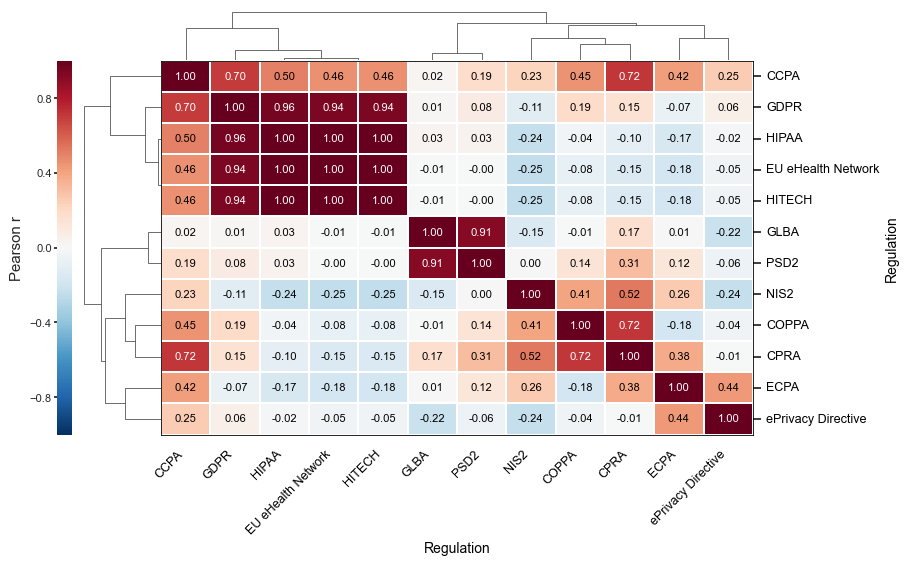

✓ Exported fig10.png at 300 DPI


In [19]:
use_cfg("fig10")
# ==============================
# Data checks and prep
# ==============================
req = {"confidence", "domain", "reg_id", "feature_clean"}
missing = req - set(merged_df.columns)
assert not missing, f"Missing required columns: {sorted(missing)}"

f12 = merged_df.loc[merged_df["confidence"] == "High"].copy()
if "year_int" in f12.columns:
    f12["year_int"] = f12["year_int"].clip(upper=2025)

mat = (
    f12.groupby(["domain", "reg_id"])["feature_clean"]
       .nunique()
       .reset_index(name="count")
)
mat["adj_count"] = mat["count"] * GLOBAL_RATE

mat_pivot = mat.pivot(index="domain", columns="reg_id", values="adj_count").fillna(0.0)

# Drop zero-variance regs
non_const = mat_pivot.columns[mat_pivot.var(axis=0) > 0]
mat_pivot = mat_pivot[non_const]
assert mat_pivot.shape[1] >= 2, "Insufficient variability across regulations to compute correlations."

reg_corr = mat_pivot.corr(method="pearson")
reg_corr.index = reg_corr.index.astype(str)
reg_corr.columns = reg_corr.columns.astype(str)

# ==============================
# Dynamic sizing
# ==============================
n_regs = reg_corr.shape[0]
height_px = max(600, min(BASE_HEIGHT_PX + n_regs * CELL_PX, 1400))
width_px  = BASE_WIDTH_PX
figsize   = (width_px / 96.0, height_px / 96.0)

print(f"Correlation matrix: {n_regs}×{n_regs}")
print(f"Figure size: {width_px}×{height_px} px")

# ==============================
# Clustermap (temporary colorbar; will be repositioned)
# ==============================
sns.set_theme(context="notebook", style="white", font_scale=0.9)

cg = sns.clustermap(
    reg_corr,
    cmap=DIVERGING_CMAP, vmin=-1, vmax=1, center=0,
    linewidths=0.2, linecolor="white",
    figsize=figsize,
    xticklabels=True, yticklabels=True,
    dendrogram_ratio=(.12, .12),
    cbar_pos=(.90, .22, .015, .56),   # placeholder; we will move it precisely below
    cbar_kws={"label": "Pearson r", "ticks": [-1, -0.5, 0, 0.5, 1], "orientation": "vertical"},
)

# White backgrounds
cg.fig.patch.set_facecolor("white")
cg.ax_heatmap.set_facecolor("white")
cg.ax_row_dendrogram.set_facecolor("white")
cg.ax_col_dendrogram.set_facecolor("white")
cg.cax.set_facecolor("white")

# Spacing for labels
cg.fig.subplots_adjust(left=0.26, bottom=0.28, right=0.94, top=0.96)

# --- Recompute layout and place colorbar safely
cg.fig.canvas.draw()  # ensure positions are updated

pos_heat = cg.ax_heatmap.get_position().bounds      # (x0, y0, w, h)
pos_rowd = cg.ax_row_dendrogram.get_position().bounds
pos_cold = cg.ax_col_dendrogram.get_position().bounds

gap = 0.008     # gap between elements
cbar_w = 0.015  # colorbar width

# Preferred: left of the row dendrogram
x_left_target = pos_rowd[0] - gap - cbar_w
left_margin   = 0.02
right_margin  = 0.02

placed_left = False
if x_left_target > left_margin:
    cg.cax.set_position([x_left_target, pos_heat[1], cbar_w, pos_heat[3]])
    placed_left = True
else:
    # Fallback: right of the heatmap
    x_right_target = pos_heat[0] + pos_heat[2] + gap
    x_right_target = min(x_right_target, 1.0 - right_margin - cbar_w)
    cg.cax.set_position([x_right_target, pos_heat[1], cbar_w, pos_heat[3]])

# Colorbar ticks
if cg.cax is not None:
    locator = MaxNLocator(nbins=5)
    if placed_left:
        cg.cax.yaxis.set_major_locator(locator)
        cg.cax.yaxis.set_ticks_position("left")
        cg.cax.yaxis.set_label_position("left")
    else:
        cg.cax.yaxis.set_major_locator(locator)
        cg.cax.yaxis.set_ticks_position("right")
        cg.cax.yaxis.set_label_position("right")
    cg.cax.tick_params(labelsize=8, length=2, pad=2)

# Tick labels
cg.ax_heatmap.set_xticklabels(
    cg.ax_heatmap.get_xticklabels(),
    rotation=45, ha="right", fontsize=9, color="black"
)
cg.ax_heatmap.set_yticklabels(
    cg.ax_heatmap.get_yticklabels(),
    rotation=0, va="center", fontsize=9, color="black"
)

# Axis labels and title
cg.ax_heatmap.set_xlabel("Regulation", fontsize=10, color="black")
cg.ax_heatmap.set_ylabel("Regulation", fontsize=10, color="black")
# cg.fig.suptitle(
#     "Similarity between regulations (domain-level distinct-feature profiles, Pearson correlation)",
#     y=0.995, fontsize=12, color="black"
# )

# Black frame
for spine in cg.ax_heatmap.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.6)
    spine.set_edgecolor("black")

# Annotate cells (clustered order)
corr_ord = cg.data2d.values
nrows, ncols = corr_ord.shape
for i in range(nrows):
    for j in range(ncols):
        v = corr_ord[i, j]
        txt_color = "white" if abs(v) >= 0.6 else "black"
        cg.ax_heatmap.text(
            j + 0.5, i + 0.5, f"{v:.2f}",
            ha="center", va="center", color=txt_color, fontsize=8
        )

plt.show()

# 300 DPI export
try:
    
    cg.fig.savefig("fig10.png", dpi=300, bbox_inches="tight", facecolor="white")
    print("✓ Exported fig10.png at 300 DPI")
except Exception as e:
    print(f"ℹ Export failed: {e}")


### Figure 11
Clustered heatmap of industry sector by regulated data category (RDC). Cells show adjusted distinct predictors with annotations. Blue palette consistent with the heatmap color scheme; the vertical colorbar sits outside labels and dendrograms.

Heatmap matrix: 12 domains × 8 RDCs
Figure size: 950×600 px; palette=BLUES_MUTED


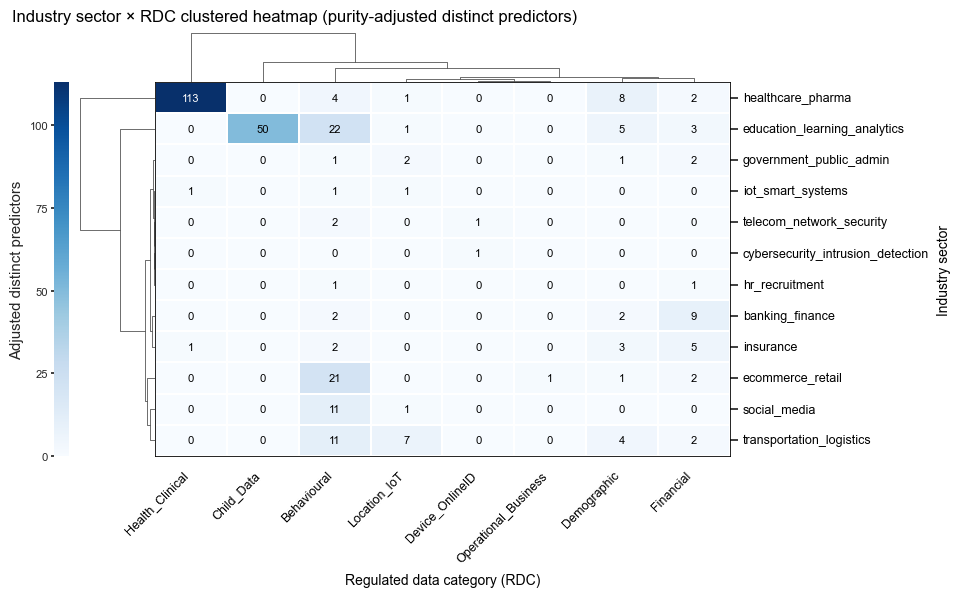

✓ Exported fig11.png at 300 DPI


In [20]:
use_cfg("fig11")
# ==============================
# Data checks and prep
# ==============================
req = {"confidence", "domain", "attribute_class", "feature_clean"}
missing = req - set(merged_df.columns)
assert not missing, f"Missing required columns: {sorted(missing)}"

f13 = merged_df.loc[merged_df["confidence"] == "High"].copy()
if "year_int" in f13.columns:
    f13["year_int"] = f13["year_int"].clip(upper=2025)

domain_attr = (
    f13.groupby(["domain", "attribute_class"])["feature_clean"]
       .nunique()
       .reset_index(name="count")
)
domain_attr["adj_count"] = (domain_attr["count"] * GLOBAL_RATE).round().astype(int)

mat = (
    domain_attr.pivot(index="domain", columns="attribute_class", values="adj_count")
              .fillna(0)
              .astype(int)
)
mat = mat.loc[mat.sum(axis=1) > 0, mat.sum(axis=0) > 0]
assert mat.shape[0] >= 2 and mat.shape[1] >= 2, "Insufficient non-empty rows/columns."

vmax = int(mat.values.max()) if mat.values.size else 0

# ==============================
# Dynamic sizing
# ==============================
n_rows = mat.shape[0]
height_px = max(600, min(BASE_HEIGHT_PX + n_rows * ROW_PX, 1400))
width_px  = BASE_WIDTH_PX
figsize   = (width_px / 96.0, height_px / 96.0)

print(f"Heatmap matrix: {mat.shape[0]} domains × {mat.shape[1]} RDCs")
print(f"Figure size: {width_px}×{height_px} px; palette=BLUES_MUTED")

# ==============================
# Clustermap (initial cbar placeholder)
# ==============================
sns.set_theme(context="notebook", style="white", font_scale=0.9)

cg = sns.clustermap(
    mat,
    cmap=SEQ_CMAP, vmin=0, vmax=vmax,
    linewidths=0.2, linecolor="white",
    figsize=figsize,
    xticklabels=True, yticklabels=True,
    dendrogram_ratio=(.12, .12),
    cbar_pos=(.90, .22, .015, .56),  # placeholder; we reposition precisely below
    cbar_kws={"label": "Adjusted distinct predictors", "orientation": "vertical"},
)

# White backgrounds
cg.fig.patch.set_facecolor("white")
cg.ax_heatmap.set_facecolor("white")
cg.ax_row_dendrogram.set_facecolor("white")
cg.ax_col_dendrogram.set_facecolor("white")
cg.cax.set_facecolor("white")

# Spacing for labels
cg.fig.subplots_adjust(left=0.28, bottom=0.28, right=0.94, top=0.96)

# Reposition colorbar to avoid overlaps (left preferred)
cg.fig.canvas.draw()
pos_heat = cg.ax_heatmap.get_position().bounds
pos_rowd = cg.ax_row_dendrogram.get_position().bounds
gap, cbarw, left_margin, right_margin = 0.008, 0.015, 0.02, 0.02

x_left_target = pos_rowd[0] - gap - cbarw
if x_left_target > left_margin:
    cg.cax.set_position([x_left_target, pos_heat[1], cbarw, pos_heat[3]])
    cg.cax.yaxis.set_ticks_position("left")
    cg.cax.yaxis.set_label_position("left")
else:
    x_right_target = min(pos_heat[0] + pos_heat[2] + gap, 1.0 - right_margin - cbarw)
    cg.cax.set_position([x_right_target, pos_heat[1], cbarw, pos_heat[3]])
    cg.cax.yaxis.set_ticks_position("right")
    cg.cax.yaxis.set_label_position("right")

cg.cax.yaxis.set_major_locator(MaxNLocator(nbins=5))
cg.cax.tick_params(labelsize=8, length=2, pad=2)

# Labels and title
cg.ax_heatmap.set_xlabel("Regulated data category (RDC)", fontsize=10, color="black", labelpad=6)
cg.ax_heatmap.set_ylabel("Industry sector", fontsize=10, color="black", labelpad=6)
cg.fig.suptitle(
    "Industry sector × RDC clustered heatmap (purity-adjusted distinct predictors)",
    y=0.995, fontsize=12, color="black"
)

# Tick labels
cg.ax_heatmap.set_xticklabels(
    cg.ax_heatmap.get_xticklabels(), rotation=45, ha="right", fontsize=9, color="black"
)
cg.ax_heatmap.set_yticklabels(
    cg.ax_heatmap.get_yticklabels(), rotation=0, va="center", fontsize=9, color="black"
)

# Black frame
for spine in cg.ax_heatmap.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.6)
    spine.set_edgecolor("black")

# Annotate all cells in clustered order
row_order = cg.dendrogram_row.reordered_ind
col_order = cg.dendrogram_col.reordered_ind
mat_ord = mat.iloc[row_order, col_order]
eps = 1e-9
for i, (_, row_vals) in enumerate(mat_ord.iterrows()):
    for j, val in enumerate(row_vals.values):
        shade = (val / (vmax + eps)) if vmax > 0 else 0.0
        txt_color = "black" if shade < 0.55 else "white"
        cg.ax_heatmap.text(
            j + 0.5, i + 0.5, f"{int(val)}",
            ha="center", va="center", color=txt_color, fontsize=8
        )

plt.show()

# 300 DPI export
try:
    cg.fig.savefig("fig11.png", dpi=300, bbox_inches="tight", facecolor="white")
    print("✓ Exported fig11.png at 300 DPI")
except Exception as e:
    print(f"Export failed: {e}")


### Figure 12
Flows from regulations to regulated data categories (RDCs). Link width encodes the proportion of each regulation’s adjusted distinct predictors directed to each RDC (normalized per regulation). Node colors use Paul Tol for regulations and Glasbey for RDCs; link colors inherit the source regulation hue.

In [21]:
use_cfg("fig12")
# ==============================
# Data checks and prep
# ==============================
req = {"confidence", "reg_id", "attribute_class", "feature_clean"}
missing = req - set(merged_df.columns)
assert not missing, f"Missing required columns: {sorted(missing)}"

f12 = merged_df.loc[
    merged_df["confidence"] == "High",
    ["reg_id", "attribute_class", "feature_clean", "year_int"]
].copy()

if "year_int" in f12.columns:
    f12["year_int"] = f12["year_int"].clip(upper=2025)

# Distinct feature links per (reg, RDC)
edge_counts = (
    f12.drop_duplicates(["reg_id", "attribute_class", "feature_clean"])
       .groupby(["reg_id", "attribute_class"])
       .size()
       .reset_index(name="w_raw")
)
edge_counts = edge_counts[edge_counts["w_raw"] >= MIN_EDGE_COUNT]
assert not edge_counts.empty, "No regulation–RDC links ≥ MIN_EDGE_COUNT."

edge_counts["w_adj"] = (edge_counts["w_raw"] * GLOBAL_RATE).round().astype(int)

# Rank regs by adjusted volume
reg_totals = edge_counts.groupby("reg_id")["w_adj"].sum().sort_values(ascending=False)

# Optional top-K filter
if TOP_K_REGS is not None:
    keep_regs = reg_totals.head(int(TOP_K_REGS)).index
    edge_counts = edge_counts[edge_counts["reg_id"].isin(keep_regs)]
    reg_totals = edge_counts.groupby("reg_id")["w_adj"].sum().sort_values(ascending=False)

# Normalize link values per reg or use adjusted counts
if NORMALISE_BY_REG:
    denom = edge_counts.groupby("reg_id")["w_adj"].transform("sum").replace(0, 1)
    edge_counts["w_norm"] = edge_counts["w_adj"] / denom
    value_col = "w_norm"; value_label = "Proportion of regulation flow"
else:
    value_col = "w_adj";  value_label = "Adjusted distinct predictors"

# Node ordering
regs  = reg_totals.index.tolist()
attrs = (edge_counts.groupby("attribute_class")[value_col]
                  .sum().sort_values(ascending=False).index.tolist())

node_labels = regs + attrs
node_index  = {name: i for i, name in enumerate(node_labels)}
sources = edge_counts["reg_id"].map(node_index).to_list()
targets = edge_counts["attribute_class"].map(node_index).to_list()
values  = edge_counts[value_col].to_list()

# Hovers
hover_links = [
    (f"{r} → {a}<br>{value_label}: {v:.2f}" if NORMALISE_BY_REG
     else f"{r} → {a}<br>{value_label}: {int(v)}")
    for r, a, v in zip(edge_counts["reg_id"], edge_counts["attribute_class"], edge_counts[value_col])
]
node_custom = []
for r in regs:
    tot = int(reg_totals.get(r, 0))
    node_custom.append(f"{r}<br>Total adjusted distinct predictors: {tot}")
attr_tot = edge_counts.groupby("attribute_class")[value_col].sum()
for a in attrs:
    node_custom.append(
        f"{a}<br>Total incoming proportion: {attr_tot.get(a, 0):.2f}"
        if NORMALISE_BY_REG else
        f"{a}<br>Total adjusted distinct predictors: {int(attr_tot.get(a, 0))}"
    )

# ==============================
# Color helpers and palettes
# ==============================
def hex_to_rgba(c, alpha=0.85):
    if isinstance(c, str) and c.startswith("#") and len(c) == 7:
        r = int(c[1:3], 16); g = int(c[3:5], 16); b = int(c[5:7], 16)
        return f"rgba({r},{g},{b},{alpha})"
    if isinstance(c, str) and c.startswith("rgb"):
        nums = re.findall(r"[\d.]+", c)
        return f"rgba({nums[0]},{nums[1]},{nums[2]},{alpha})"
    return c

def to_hex_list(p):
    if not p: return []
    if isinstance(p[0], str) and p[0].startswith("#"):
        return list(p)
    out = []
    for r, g, b in p:
        out.append(f"#{int(round(r*255)):02X}{int(round(g*255)):02X}{int(round(b*255)):02X}")
    return out

def hsv_hex(n, s=0.70, v=0.86):
    cols = []
    for i in range(n):
        h = (i / float(n)) % 1.0
        r, g, b = colorsys.hsv_to_rgb(h, s, v)
        cols.append(f"#{int(r*255):02X}{int(g*255):02X}{int(b*255):02X}")
    return cols

# Regulations: Paul Tol qualitative
TOL_MUTED  = ["#CC6677", "#332288", "#DDCC77", "#117733", "#88CCEE",
              "#882255", "#44AA99", "#999933", "#AA4499"]
TOL_MEDIUM = ["#6699CC", "#004488", "#EECC66", "#994455", "#997700", "#EE99AA"]
TOL_ALL = TOL_MUTED + TOL_MEDIUM
reg_pal = (TOL_ALL * int(np.ceil(len(regs)/len(TOL_ALL))))[:len(regs)]
REG_COLOR_MAP = {r: reg_pal[i] for i, r in enumerate(regs)}

try:
    cand = []
    for name in ("glasbey", "glasbey_light", "glasbey_cool", "glasbey_warm", "glasbey_dark"):
        p = getattr(cc, name, [])
        cand.extend(to_hex_list(list(p)))
    # Deduplicate preserving order
    seen, palette_attrs = set(), []
    for c in cand:
        if c not in seen:
            seen.add(c); palette_attrs.append(c)
    if len(palette_attrs) < len(attrs):
        palette_attrs.extend(hsv_hex(len(attrs) - len(palette_attrs)))
except Exception:
    palette_attrs = hsv_hex(len(attrs))

RDC_COLOR_MAP = {a: palette_attrs[i] for i, a in enumerate(attrs)}

reg_node_colors  = [hex_to_rgba(REG_COLOR_MAP[r], 0.95) for r in regs]
attr_node_colors = [hex_to_rgba(RDC_COLOR_MAP[a], 0.95) for a in attrs]
node_colors = reg_node_colors + attr_node_colors
link_colors = [hex_to_rgba(REG_COLOR_MAP[r], 0.40) for r in edge_counts["reg_id"]]

# ==============================
# Figure
# ==============================
height_px = max(540, 26 * max(len(regs), len(attrs)))
fig12 = go.Figure(data=[go.Sankey(
    arrangement="snap",
    node=dict(
        pad=18, thickness=16,
        label=node_labels,
        color=node_colors,
        customdata=node_custom,
        hovertemplate="%{customdata}<extra></extra>",
        line=dict(color="black", width=0.5)
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values,
        customdata=hover_links,
        color=link_colors,
        hovertemplate="%{customdata}<extra></extra>"
    )
)])

fig12.update_layout(
    width=BASE_WIDTH_PX,
    height=height_px,
    font=dict(family=FONT_FAMILY, size=10, color="black"),
    paper_bgcolor="white",
    plot_bgcolor="white",
    margin=dict(l=80, r=80, t=40, b=40),
    title=None,
)

# High-quality export config (camera button)
config = {
    "toImageButtonOptions": {
        "format": "png",
        "filename": "fig12",
        "height": height_px,
        "width": BASE_WIDTH_PX,
        "scale": EXPORT_SCALE,
    },
    "displayModeBar": True,
    "displaylogo": False,
    "modeBarButtonsToRemove": ["pan2d", "lasso2d", "select2d", "zoom2d"],
}

fig12.show(config=config)

print("="*70)
print("Figure 14 Configuration:")
print(f"  Dimensions: {BASE_WIDTH_PX}×{height_px} px")
print(f"  Export size: {BASE_WIDTH_PX*EXPORT_SCALE}×{height_px*EXPORT_SCALE} px (300 DPI)")
print(f"  Normalized by regulation: {NORMALISE_BY_REG}")
print(f"  Nodes: {len(regs)} regs → {len(attrs)} RDCs; links: {len(values)}")
print("="*70)

try:
    fig12.write_image("fig12.png", format="png",
                      width=BASE_WIDTH_PX, height=height_px, scale=EXPORT_SCALE)
    print("✓ Auto-exported fig12.png")
except Exception:
    print("ℹ Use the camera icon to download at 300 DPI")


Figure 14 Configuration:
  Dimensions: 950×540 px
  Export size: 2850×1620 px (300 DPI)
  Normalized by regulation: True
  Nodes: 11 regs → 6 RDCs; links: 23


✓ Auto-exported fig12.png


### Figure 13
Descriptive Pearson residuals for regulation–regulated data category associations and the largest absolute residual contributions. The following cell also retains exploratory significance diagnostics from an earlier analysis. Its probability values, false discovery rate stars, and significance-based opacity are not used for inference in the manuscript because the aggregated entries include repeated predictor and paper contributions.

In [22]:
use_cfg("fig13")


# ==============================
# Data checks and prep
# ==============================
req = {"confidence", "reg_id", "attribute_class", "feature_clean"}
missing = req - set(merged_df.columns)
assert not missing, f"Missing required columns: {sorted(missing)}"

f13 = merged_df.loc[
    merged_df["confidence"] == "High",
    ["reg_id", "attribute_class", "feature_clean", "year_int"]
].copy()
if "year_int" in f13.columns:
    f13["year_int"] = f13["year_int"].clip(upper=2025)

# Distinct features per (reg, RDC)
tab_raw = (
    f13.drop_duplicates(["reg_id", "attribute_class", "feature_clean"])
       .groupby(["reg_id", "attribute_class"])
       .size().unstack(fill_value=0)
       .astype(int)
)

# Purity-adjusted table
tab = (tab_raw * GLOBAL_RATE).round().astype(int)

# Keep only non-empty regs/classes
tab = tab.loc[tab.sum(axis=1) > 0, tab.sum(axis=0) > 0]
assert tab.shape[0] >= 2 and tab.shape[1] >= 2, "Insufficient data for χ² (need ≥2 regs and ≥2 classes)."

# ==============================
# Multiple testing configuration
# ==============================
MTC_METHOD = "bh"          # options: "bh" (Benjamini–Hochberg FDR) or "bonferroni"
ALPHA       = 0.05          # family-wise level (α) or FDR (q)
EXCLUDE_LOW_EXPECTED = False
EXPECTED_MIN = 5.0          # if EXCLUDE_LOW_EXPECTED=True, cells with expected < this are not tested

def _adjust_pvals(pvals_flat: np.ndarray, method: str) -> np.ndarray:
    p = np.asarray(pvals_flat, dtype=float)
    m = p.size
    if m == 0:
        return p
    if method.lower() in {"bonferroni", "bonf"}:
        return np.minimum(p * m, 1.0)
    # Benjamini–Hochberg (FDR)
    order = np.argsort(p)
    ranks = np.arange(1, m + 1)  # 1..m
    p_sorted = p[order]
    padj_sorted = (m / ranks) * p_sorted
    # enforce monotonicity
    padj_sorted = np.minimum.accumulate(padj_sorted[::-1])[::-1]
    padj = np.empty_like(p)
    padj[order] = np.clip(padj_sorted, 0.0, 1.0)
    return padj

def _hex_to_rgba(hex_color: str, alpha: float) -> str:
    h = hex_color.lstrip("#")
    r, g, b = (int(h[i:i+2], 16) for i in (0, 2, 4))
    return f"rgba({r},{g},{b},{alpha})"

# ==============================
# χ² test, residuals, effect size
# ==============================
chi2, p, dof, expected = chi2_contingency(tab.values, correction=False)

# --- after chi2, p, dof, expected = chi2_contingency(...)

# Assumption check
exp = np.asarray(expected, dtype=float)
prop_ge5 = float((exp >= 5).mean())
emin = float(exp.min())
assump_ok = (prop_ge5 >= 0.80) and (emin >= 1.0)

# Report in console
print(f"Expected-counts check: >=5 in {prop_ge5*100:.1f}%, min(E)={emin:.2f} -> OK={assump_ok}")

# Monte-Carlo p-value for omnibus χ² (independence with product-marginal probs; approximate)
p_mc = np.nan
if not assump_ok:
    rng = np.random.default_rng(42)
    B = 10000
    Ntot = int(tab.values.sum())
    probs = exp / exp.sum()
    chi2_sim = np.empty(B)
    for b in range(B):
        draw = rng.multinomial(Ntot, probs.ravel()).reshape(exp.shape)
        exp_b = draw.sum(axis=1, keepdims=True) @ draw.sum(axis=0, keepdims=True) / Ntot
        chi2_sim[b] = np.where(exp_b > 0, (draw - exp_b)**2 / exp_b, 0).sum()
    p_mc = float((chi2_sim >= chi2).mean())
    print(f"Monte-Carlo omnibus p (B={B}): {p_mc:.3e}")

# Exclude low-expected cells from the per-cell family if you want prose to match
EXCLUDE_LOW_EXPECTED = True
EXPECTED_MIN = 5.0





n = int(tab.values.sum())
r, c = tab.shape
cramers_v = float(np.sqrt(chi2 / (n * (min(r - 1, c - 1)))))

resid = (tab.values - expected) / np.sqrt(expected)
resid_df = pd.DataFrame(resid, index=tab.index, columns=tab.columns)

# Effect size label thresholds (Cramér’s V)
if min(r - 1, c - 1) == 1:
    thresholds = (0.10, 0.30, 0.50)
else:
    thresholds = (0.07, 0.21, 0.35)
if   cramers_v >= thresholds[2]: v_label = "large"
elif cramers_v >= thresholds[1]: v_label = "medium"
elif cramers_v >= thresholds[0]: v_label = "small"
else:                             v_label = "negligible"

# Robust z-limits
ZMAX_Q = 0.995
zmax = float(np.nanquantile(np.abs(resid_df.values), ZMAX_Q))
if not np.isfinite(zmax) or zmax <= 0:
    zmax = 0.01

# ==============================
# Per-cell p-values and correction
# ==============================
# two-sided normal approx from standardized residuals
z_mat = resid_df.values.astype(float)
p_mat = 2.0 * (1.0 - norm.cdf(np.abs(z_mat)))

# Optionally exclude low-expected cells from the tested family
if EXCLUDE_LOW_EXPECTED:
    exp_mask = (expected >= EXPECTED_MIN)
    p_vec = p_mat[exp_mask].ravel()
else:
    exp_mask = np.ones_like(p_mat, dtype=bool)
    p_vec = p_mat.ravel()

m_tests = p_vec.size
p_adj_vec = _adjust_pvals(p_vec, MTC_METHOD)
# rebuild full matrix of adjusted p, with NaN where excluded
p_adj_mat = np.full_like(p_mat, np.nan, dtype=float)
p_adj_mat[exp_mask] = p_adj_vec.reshape(p_mat[exp_mask].shape)

sig_mat = (p_adj_mat <= ALPHA)

# ==============================
# Figure 13 — heatmap with adjusted significance
# ==============================
method_label = "BH-FDR" if MTC_METHOD.lower().startswith("bh") else "Bonferroni"
title_main = (f"Regulation × RDC — χ²={chi2:.2f}, df={dof}, p={p:.3e}, "
              f"Cramér’s V={cramers_v:.3f} ({v_label})"
              f"<br><sup>Per-cell significance: {method_label}, α={ALPHA}, m={m_tests} tests; "
              f"★ = adjusted p ≤ α</sup>")

heat = go.Heatmap(
    z=resid_df.values,
    x=resid_df.columns.tolist(),
    y=resid_df.index.tolist(),
    zmin=-zmax, zmax=zmax, zmid=0,
    colorscale=BLUE_DIVERGING,
    colorbar=dict(
        title=dict(text="Standardized residual (z)", side="top"),
        orientation="h",
        x=0.5, xanchor="center",
        y=1.12, yanchor="bottom",
        len=0.65, thickness=15,
        bgcolor="white",
        outlinecolor="rgba(0,0,0,0.3)", outlinewidth=1,
        tickfont=dict(size=9, color="black"),
    ),
    hovertemplate="Regulation: %{y}<br>RDC: %{x}<br>z: %{z:.2f}<extra></extra>",
)

height_px = max(540, 26 * len(resid_df.index))
fig13 = go.Figure(data=[heat])
fig13.update_layout(
    width=BASE_WIDTH_PX,
    height=height_px,
    font=dict(family=FONT_FAMILY, size=10, color="black"),
    paper_bgcolor="white",
    plot_bgcolor="white",
    margin=dict(l=120, r=60, t=100, b=80),
    xaxis=dict(
        title="Regulated data category (RDC)",
        tickangle=45,
        showgrid=False,
        showline=True, linecolor="black", linewidth=1, mirror=True,
        ticks="outside",
        tickfont=dict(size=9, color="black"),
    ),
    yaxis=dict(
        title="Regulation",
        autorange="reversed",
        showgrid=False,
        showline=True, linecolor="black", linewidth=1, mirror=True,
        ticks="outside",
        tickfont=dict(size=9, color="black"),
    ),
    title=dict(text=title_main, x=0.5, xanchor="center", font=dict(size=12, color="black")),
)

# Per-cell labels with adjusted significance stars
for i, reg in enumerate(resid_df.index):
    for j, rdc in enumerate(resid_df.columns):
        z = float(z_mat[i, j])
        star = "★" if (sig_mat[i, j] if np.isfinite(p_adj_mat[i, j]) else False) else ""
        txt = f"{z:+.2f}{star}"
        color = "white" if abs(z) >= LABEL_WHITE_THRESHOLD_FRAC * zmax else "black"
        fig13.add_annotation(
            x=rdc, y=reg, text=txt, showarrow=False,
            xanchor="center", yanchor="middle",
            font=dict(size=9, color=color)
        )

# Export config
config = {
    "toImageButtonOptions": {
        "format": "png",
        "filename": "fig13",
        "height": height_px,
        "width": BASE_WIDTH_PX,
        "scale": EXPORT_SCALE,
    },
    "displayModeBar": True,
    "displaylogo": False,
    "modeBarButtonsToRemove": ["pan2d", "lasso2d", "select2d", "zoom2d"],
}
fig13.show(config=config)

print("="*70)
print("Figure 13 Configuration:")
print(f"  Dimensions: {BASE_WIDTH_PX}×{height_px} px")
print(f"  Export size: {BASE_WIDTH_PX*EXPORT_SCALE}×{height_px*EXPORT_SCALE} px (300 DPI)")
print(f"  χ²={chi2:.2f}, df={dof}, p={p:.3e}, Cramér’s V={cramers_v:.3f} ({v_label})")
print(f"  zmax (|z|, q={ZMAX_Q}): {zmax:.2f}; label flip @ {LABEL_WHITE_THRESHOLD_FRAC*zmax:.2f}")
print("="*70)

# ==============================
# Multiple testing summary
# ==============================
n_sig = int(np.nansum(sig_mat))
n_pos = int(np.nansum((z_mat > 0) & sig_mat))
n_neg = int(np.nansum((z_mat < 0) & sig_mat))
print("="*70)
print("Multiple testing summary:")
print(f"  Method: {method_label}, alpha={ALPHA}")
print(f"  Tested cells (m): {m_tests}")
print(f"  Significant cells: {n_sig}  (pos: {n_pos}, neg: {n_neg})")
if EXCLUDE_LOW_EXPECTED:
    n_excl = int((~exp_mask).sum())
    print(f"  Excluded for expected<{EXPECTED_MIN}: {n_excl}")
print("="*70)

# ==============================
# Figure 13b — Top |z| with adjusted p, significance via RGBA opacity
# ==============================
try:
    abs_res = resid_df.stack(future_stack=True).rename("z").reset_index()
except TypeError:
    abs_res = resid_df.stack(dropna=False).rename("z").reset_index()
abs_res.columns = ["Regulation", "Attribute class", "z"]
abs_res["abs_z"] = abs_res["z"].abs()

# align adjusted p to stacked order (row-major)
p_adj_series = pd.Series(p_adj_mat.reshape(-1))
abs_res["p"] = (2.0 * (1.0 - norm.cdf(abs_res["abs_z"].astype(float))))
abs_res["p_adj"] = p_adj_series.values
abs_res["sig"] = abs_res["p_adj"] <= ALPHA

topK = 12
top_tbl = abs_res.sort_values("abs_z", ascending=False).head(topK).copy()
bar_colors = np.where(top_tbl["z"] >= 0, POS_BAR, NEG_BAR)
bar_opacity = np.where(top_tbl["sig"], 1.0, 0.35)
marker_colors = [_hex_to_rgba(col, float(op)) for col, op in zip(bar_colors, bar_opacity)]

# Observed and expected for hover
obs_vals = [int(tab.loc[r, a]) for r, a in zip(top_tbl["Regulation"], top_tbl["Attribute class"])]
exp_vals = [float(expected[tab.index.get_loc(r), tab.columns.get_loc(a)])
            for r, a in zip(top_tbl["Regulation"], top_tbl["Attribute class"])]

hover_lines = [
    (f"Regulation: {r}<br>RDC: {a}"
     f"<br>z: {z:+.2f}"
     f"<br>Obs (adj): {o}<br>Exp: {e:.1f}"
     f"<br>p: {pval:.3e}<br>adj p ({method_label}): {padj:.3e}"
     f"<br>significant@α={ALPHA}: {'yes' if sg else 'no'}")
    for r, a, z, o, e, pval, padj, sg in zip(
        top_tbl["Regulation"], top_tbl["Attribute class"], top_tbl["z"],
        obs_vals, exp_vals, top_tbl["p"], top_tbl["p_adj"], top_tbl["sig"])
]

h_px = max(520, 22 * top_tbl.shape[0])
fig13b = go.Figure(go.Bar(
    x=top_tbl["abs_z"][::-1],
    y=(top_tbl["Regulation"] + " ⟶ " + top_tbl["Attribute class"])[::-1],
    orientation="h",
    marker=dict(color=marker_colors[::-1], line=dict(color="black", width=0.5)),
    hovertext=hover_lines[::-1],
    hovertemplate="%{hovertext}<extra></extra>"
))
fig13b.update_layout(
    width=BASE_WIDTH_PX,
    height=h_px,
    font=dict(family=FONT_FAMILY, size=10, color="black"),
    paper_bgcolor="white",
    plot_bgcolor="white",
    margin=dict(l=260, r=60, t=80, b=60),
    xaxis=dict(
        title="|z| (contribution magnitude)",
        showgrid=True, gridcolor="#e5e5e5",
        zeroline=False,
        showline=True, linecolor="black", linewidth=1, mirror=True,
        ticks="outside",
        tickfont=dict(size=9, color="black"),
    ),
    yaxis=dict(
        title=f"Regulation ⟶ RDC   (opacity=1 if adj p≤{ALPHA}, else 0.35)",
        showgrid=False,
        showline=True, linecolor="black", linewidth=1, mirror=True,
        ticks="outside",
        tickfont=dict(size=9, color="black"),
    ),
    title=dict(text=f"Top |residual| contributors to χ² (k={topK}) — {method_label} at α={ALPHA}",
               x=0.5, xanchor="center", font=dict(size=12)),
)
fig13b.show(config=config)

try:
    fig13.write_image("fig13_1.png", format="png",
                     width=fig13.layout.width, height=fig13.layout.height, scale=EXPORT_SCALE)
    print("✓ Auto-exported fig13_1.png")
except Exception:
    print("ℹ Use the camera button to download at 300 DPI")

try:
    fig13b.write_image("fig13_2.png", format="png",
                     width=fig13b.layout.width, height=fig13b.layout.height, scale=EXPORT_SCALE)
    print("✓ Auto-exported fig13_2.png")
except Exception:
    print("ℹ Use the camera button to download at 300 DPI")


Expected-counts check: >=5 in 27.8%, min(E)=0.00 -> OK=False
Monte-Carlo omnibus p (B=10000): 0.000e+00


/var/folders/sy/hk3f7z4x39z485grf7qhpx2x7t28dr/T/ipykernel_61736/3760080377.py:91: RuntimeWarning:

invalid value encountered in divide



Figure 13 Configuration:
  Dimensions: 950×540 px
  Export size: 2850×1620 px (300 DPI)
  χ²=1912.64, df=88, p=0.000e+00, Cramér’s V=0.542 (large)
  zmax (|z|, q=0.995): 18.64; label flip @ 12.12
Multiple testing summary:
  Method: BH-FDR, alpha=0.05
  Tested cells (m): 30
  Significant cells: 24  (pos: 6, neg: 18)
  Excluded for expected<5.0: 78


✓ Auto-exported fig13_1.png


✓ Auto-exported fig13_2.png


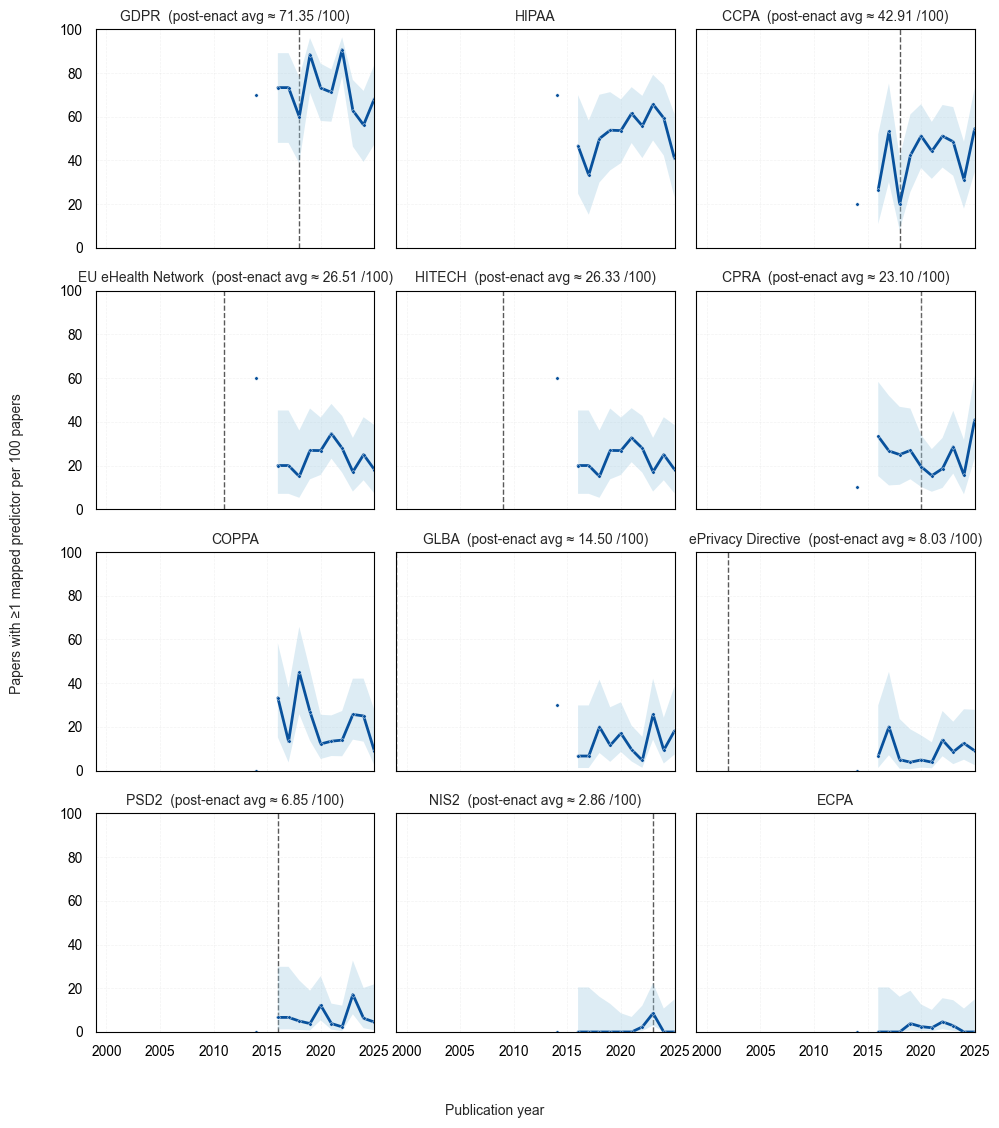

✓ Exported fig14.png at 300 DPI (950×1120 px)


In [23]:
# ----------------- CONFIG -----------------
MAX_YEAR = 2025
MIN_PAPERS_PER_YEAR = 10
SMOOTH_K = 1                     # moving average window for prevalence line; CI stays unsmoothed
REQUIRE_STATUS_REGULATED = True
PAPER_ID_COLS = ["doi", "paper_id", "document_id", "paper_uid"]
Z_95 = 1.96

# Styling
LINE_COLOR = "#08519c"           # dark blue
BAND_COLOR = "#9ecae1"           # light blue
AX_LINE = "black"

BASE_WIDTH_PX  = 950
ROW_HEIGHT_PX  = 280             # per-row height target
EXPORT_SCALE   = 3
FONT_FAMILY    = "Arial"

# ----------------- IMPORTS -----------------

mpl.rcParams.update({
    "font.family": FONT_FAMILY,
    "font.size": 10,
    "axes.edgecolor": AX_LINE,
    "axes.linewidth": 1.0,
    "xtick.color": "black",
    "ytick.color": "black",
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})

# ----------------- INPUT / PREP -----------------
df = merged_df.copy()
df["year_int"] = df["year_int"].clip(upper=MAX_YEAR)

# enactment mapping
_ENACT = globals().get("ENACT_YEARS", globals().get("enact_years", None))
assert isinstance(_ENACT, dict) and len(_ENACT) > 0, "Define ENACT_YEARS or enact_years as {reg_id: year}"

# detect paper id column
paper_col = next((c for c in PAPER_ID_COLS if c in df.columns), None)
assert paper_col is not None, f"Provide a paper id column among: {PAPER_ID_COLS}"

# denominator: distinct papers/year
papers_by_year = (
    df.dropna(subset=[paper_col, "year_int"])
      .drop_duplicates([paper_col])
      .groupby("year_int").size()
      .rename("n_papers").astype(int).to_frame()
)
year_min = int(df["year_int"].min())
years = pd.Index(range(year_min, MAX_YEAR + 1), name="year_int")
papers_by_year = papers_by_year.reindex(years, fill_value=0)

# numerator: papers with ≥1 mapped predictor per regulation × year
cols = ["reg_id", paper_col, "year_int", "confidence"]
if REQUIRE_STATUS_REGULATED:
    cols.append("status")

x = df.loc[:, [c for c in cols if c in df.columns]].copy()
x = x[x["confidence"].eq("High")]
if REQUIRE_STATUS_REGULATED and "status" in x.columns:
    x = x[x["status"].eq("Regulated")]

num = (
    x.dropna(subset=["reg_id", paper_col, "year_int"])
     .drop_duplicates(["reg_id", paper_col, "year_int"])
     .groupby(["reg_id", "year_int"]).size()
     .rename("k_papers_with_reg").to_frame().reset_index()
)

# complete reg × year grid and attach denominators
all_regs = sorted(df["reg_id"].dropna().unique().tolist())
grid = pd.MultiIndex.from_product([all_regs, years], names=["reg_id", "year_int"])
prev = (num.set_index(["reg_id", "year_int"])
            .reindex(grid).reset_index()
            .merge(papers_by_year.reset_index(), on="year_int", how="left"))
prev["k_papers_with_reg"] = prev["k_papers_with_reg"].fillna(0).astype(int)
prev["n_papers"] = prev["n_papers"].fillna(0).astype(int)

# Wilson prevalence per 100 with CI
k = prev["k_papers_with_reg"].astype(float)
n = prev["n_papers"].astype(float)
mask_ok = n >= MIN_PAPERS_PER_YEAR
p_hat = np.divide(k, n, out=np.zeros_like(k), where=n > 0)

n_safe = n.replace(0, np.nan)
den = 1.0 + (Z_95**2)/n_safe
center = (p_hat + (Z_95**2)/(2*n_safe)) / den
half = (Z_95 * np.sqrt((p_hat*(1 - p_hat))/n_safe + (Z_95**2)/(4*n_safe**2))) / den

prev["prev_per_100"] = np.where(mask_ok, 100.0 * p_hat, np.nan)
prev["ci_lo"] = np.where(mask_ok, 100.0 * np.maximum(0.0, center - half), np.nan)
prev["ci_hi"] = np.where(mask_ok, 100.0 * np.minimum(1.0, center + half), np.nan)

# optional smoothing
rate_col = "prev_per_100"
if SMOOTH_K > 1:
    prev["prev_smooth"] = (
        prev.sort_values(["reg_id", "year_int"])
            .groupby("reg_id")[rate_col]
            .transform(lambda s: s.rolling(SMOOTH_K, min_periods=1).mean())
    )
    rate_col = "prev_smooth"

# panel order: mean post-enactment prevalence
order_scores = []
for reg, g in prev[["reg_id", "year_int", rate_col]].groupby("reg_id", dropna=True):
    yr = _ENACT.get(reg, None)
    g = g.sort_values("year_int")
    m = g.loc[g["year_int"] >= int(yr)] if isinstance(yr, (int, float)) else g
    order_scores.append((reg, float(m[rate_col].mean(skipna=True))))
regs = [r for r, _ in sorted(order_scores, key=lambda t: t[1], reverse=True)]
if len(regs) == 0:
    raise ValueError("No regulations to display after filtering.")

# ----------------- PLOT -----------------
n = len(regs)
ncols = 3
nrows = int(np.ceil(n / ncols))
width_in  = BASE_WIDTH_PX / 96.0
height_px = max(600, int(ROW_HEIGHT_PX * nrows))
height_in = height_px / 96.0

fig, axes = plt.subplots(nrows, ncols, figsize=(width_in, height_in), sharex=True, sharey=True)
axes = np.asarray(axes).reshape(-1)

ymax = float(np.nanmax(prev[rate_col])) if np.isfinite(np.nanmax(prev[rate_col])) else 0.0
ymax = min(100.0, max(5.0, ymax * 1.2))

for i, reg in enumerate(regs):
    ax = axes[i]
    sub = (prev[prev["reg_id"] == reg]
           .set_index("year_int")
           .reindex(years))

    y  = sub[rate_col].to_numpy(dtype=float)
    lo = sub["ci_lo"].to_numpy(dtype=float)
    hi = sub["ci_hi"].to_numpy(dtype=float)

    # CI band (light blue)
    ax.fill_between(years, lo, hi, color=BAND_COLOR, alpha=0.35, linewidth=0, where=~np.isnan(lo) & ~np.isnan(hi))

    # prevalence line + markers (dark blue)
    ax.plot(years, y, lw=2, color=LINE_COLOR, marker="o", ms=2.5, mfc=LINE_COLOR, mec="white", mew=0.3)

    # enactment marker and panel title with post-enactment mean
    yr = _ENACT.get(reg, None)
    if isinstance(yr, (int, float)) and int(yr) >= years.min():
        yr = int(min(int(yr), MAX_YEAR))
        ax.axvline(yr, color="0.35", lw=1, ls="--", zorder=0)
        post_avg = float(pd.Series(y, index=years).loc[years >= yr].mean(skipna=True))
        ax.set_title(f"{reg}  (post-enact avg ≈ {post_avg:.2f} /100)", fontsize=10)
    else:
        ax.set_title(f"{reg}", fontsize=10)

    # axes styling
    ax.set_ylim(0, ymax)
    ax.set_xlim(years.min(), MAX_YEAR)
    ax.grid(alpha=0.25, linestyle="--", linewidth=0.5)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.8)
        spine.set_edgecolor(AX_LINE)

# hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

# global labels
# fig.suptitle("Annual prevalence of papers with ≥1 mapped predictor per regulation (per 100 decision-tree papers)",
#              fontsize=12, y=0.995)
fig.text(0.5, 0.01, "Publication year", ha="center", fontsize=10)
fig.text(0.01, 0.5, "Papers with ≥1 mapped predictor per 100 papers",
         va="center", rotation="vertical", fontsize=10)

plt.tight_layout(rect=[0.045, 0.045, 1.0, 0.97])

# on-screen
plt.show()

# export at 300 DPI
try:
    fig.savefig("fig14.png", dpi=300, bbox_inches="tight", facecolor="white")
    print(f"✓ Exported fig14.png at 300 DPI ({BASE_WIDTH_PX}×{height_px} px)")
except Exception as e:
    print(f"Export failed: {e}")


## Summary of Findings

This study characterizes the regulatory reporting surface of predictor variables explicitly reported in the retained decision-tree literature.

- **Sectors.** Healthcare/Pharma contributes over half of regulated-predictor records; Education/Learning Analytics becomes the largest share by 2023-2025; Transportation/Logistics peaks in the mid-2010s.
- **Regulations.** GDPR and HIPAA dominate; HITECH and the EU eHealth Network deepen healthcare; COPPA concentrates in education; GLBA is mainly banking/finance; ePrivacy shows a transportation pocket; NIS2 and ECPA remain sparse.
- **Regulated data categories.** Health_Clinical leads; Behavioural and Demographic follow; Location_IoT and Financial are moderate; identifier/contact classes are rare.
- **Timing.** Regulated-predictor counts cluster in 2020-2022 across multiple frameworks rather than exactly at $E_r$, with GDPR peaking near 2021.

These measurements identify sector–regulation–category combinations for documentation review and subsequent privacy analysis. They characterize the retained published literature and do not establish organizational uptake, legal applicability, or compliance.
